# Assignment 2: Fashion-MNIST Comparison

**Research question:** How much does a simple convolutional neural network (CNN) improve Fashion-MNIST image classification performance relative to classical machine learning baselines?

## Datset note
A personal dataset was not used because my first assignment didn't turn out well and it was suggested I use a different datset. Thus, I've decided to use the Fashion-MNIST dataset, as we briefly worked with it in class and is an image classification dataset which I can understand why it would be helpful in the real world.

## 1. Data Explanation

This project uses **Fashion-MNIST**, a dataset of grayscale clothing images introduced by Xiao, Rasul, and Vollgraf (2017). The dataset contains:

- `60,000` training images
- `10,000` test images
- `10` clothing categories
- one `28 x 28` grayscale image per item

The ten classes are:

1. T-shirt/top
2. Trouser
3. Pullover
4. Dress
5. Coat
6. Sandal
7. Shirt
8. Sneaker
9. Bag
10. Ankle boot

### Why this dataset was chosen

I chose this dataset because my first assignment suffered from weak predictive signal. Fashion-MNIST provides a much cleaner supervised-learning setting where:

- the labels are already defined,
- the class balance is uniform,
- the visual differences between some classes are obvious and others are subtle,
- and both classical models and deep-learning models can be compared meaningfully.

### How the data was obtained

In this notebook the data is obtained through the `torchvision` dataset interface, which downloads the official Fashion-MNIST files and exposes them as Python objects.

### How the sample is formed

To keep the notebook fast enough to rerun on a normal laptop CPU, I use:

- a stratified working training sample of `10,000` images,
- a stratified validation sample of `2,000` images,
- and the official `10,000` image test split as the final out-of-sample evaluation set.

This stratification strategy preserves the original class balance, so the reduced sample still represents the full dataset fairly.

In [93]:
import os
import copy
import random
import time
import warnings
from pathlib import Path

# Matplotlib writes a config directory on first import. Creating a local
# writable directory avoids permission warnings inside the notebook runtime.
mpl_dir = Path.cwd() / ".matplotlib"
mpl_dir.mkdir(exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(mpl_dir)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
from IPython.display import Markdown, display

from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import FashionMNIST

sns.set_theme(style="whitegrid", context="talk")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

WORKING_TRAIN_SIZE = 10_000
WORKING_VAL_SIZE = 2_000
BATCH_SIZE = 128
EPOCHS = 12
PATIENCE = 3

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print(f"Using device: {DEVICE}")

Using device: mps


## 2. Converting the Data to Python-Readable Format

The raw Fashion-MNIST files are stored in IDX format. Instead of parsing those files manually, this notebook uses `torchvision.datasets.FashionMNIST`, which:

- downloads the official files,
- verifies and reads them,
- exposes the pixel grids as tensor-backed arrays,
- and makes the labels available alongside the images.

This section is the model's "data ingestion" layer, converting external files into Python data structures that the rest of the analysis can use.

The code below:

- downloads or loads the dataset,
- converts images to NumPy arrays scaled to `[0, 1]`,
- creates a stratified train/validation split from the official training data,
- and prepares both image-shaped arrays and flattened arrays for later models.

In [94]:
data_root = Path.cwd() / "data"

# Load the official Fashion-MNIST training and test datasets.
train_full = FashionMNIST(root=data_root, train=True, download=True)
test_full = FashionMNIST(root=data_root, train=False, download=True)

# Convert the image data into NumPy arrays and rescale pixels from
# integer values in [0, 255] to floating point values in [0, 1].
X_full = train_full.data.numpy().astype("float32") / 255.0
y_full = train_full.targets.numpy()
X_test = test_full.data.numpy().astype("float32") / 255.0
y_test = test_full.targets.numpy()

# Create a manageable working subset from the official training data.
working_indices, _ = train_test_split(
    np.arange(len(y_full)),
    train_size=WORKING_TRAIN_SIZE + WORKING_VAL_SIZE,
    stratify=y_full,
    random_state=SEED,
)

# Split that subset into training and validation partitions.
train_idx, val_idx = train_test_split(
    working_indices,
    train_size=WORKING_TRAIN_SIZE,
    stratify=y_full[working_indices],
    random_state=SEED,
)

X_train = X_full[train_idx]
y_train = y_full[train_idx]
X_val = X_full[val_idx]
y_val = y_full[val_idx]

# Classical models in scikit-learn expect tabular feature vectors, so
# we also keep flattened versions of each image.
X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat = X_val.reshape(len(X_val), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

split_summary = pd.DataFrame(
    [
        {"Split": "Train", "Samples": len(X_train), "Image shape": X_train.shape[1:]},
        {"Split": "Validation", "Samples": len(X_val), "Image shape": X_val.shape[1:]},
        {"Split": "Test", "Samples": len(X_test), "Image shape": X_test.shape[1:]},
    ]
)
display(split_summary)

,Split,Samples,Image shape
0,Train,10000,"(28, 28)"
1,Validation,2000,"(28, 28)"
2,Test,10000,"(28, 28)"


At this point the data exists in two parallel forms:

- **Image tensors** with shape `(n, 28, 28)` for the CNN.
- **Flattened feature vectors** with shape `(n, 784)` for classical scikit-learn models.

That distinction is important. Flattened vectors ignore spatial arrangement, while CNNs preserve local neighborhoods of pixels. Much of the later comparison is really about whether preserving that structure matters.

## 3. Cleaning, Pre-Processing, Feature Engineering, and Exploratory Data Analysis

This dataset is already much cleaner than my first assignment's Toggl data. There are no missing labels, no duplicate columns, no mixed file formats, and a very clean distinction between objects. Even so, some preprocessing is still required.

### Cleaning and preprocessing choices

- **Pixel scaling:** raw pixel values are scaled from `0-255` to `0-1`.
- **Flattening for classical models:** logistic regression and Naive Bayes need tabular vectors rather than 2D images.
- **PCA for dimensionality reduction:** principal component analysis is used as a feature-engineering step before one of the logistic-regression models.

### Why EDA matters here

Before fitting any model, EDA is useful to verify:

- whether the classes are balanced,
- what the images actually look like,
- whether some classes look visually similar,
- and whether the basic summary statistics suggest any obvious issues.

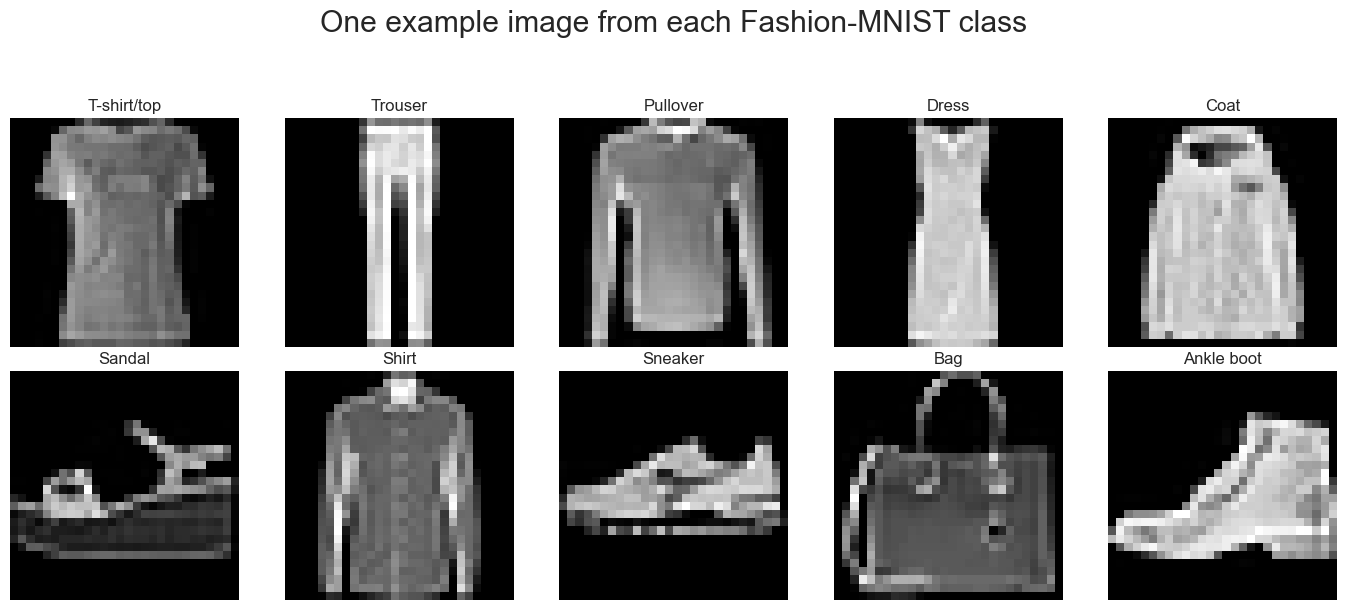

,Class,Train,Validation,Test
0,T-shirt/top,1000,200,1000
1,Trouser,1000,200,1000
2,Pullover,1000,200,1000
3,Dress,1000,200,1000
4,Coat,1000,200,1000
5,Sandal,1000,200,1000
6,Shirt,1000,200,1000
7,Sneaker,1000,200,1000
8,Bag,1000,200,1000
9,Ankle boot,1000,200,1000


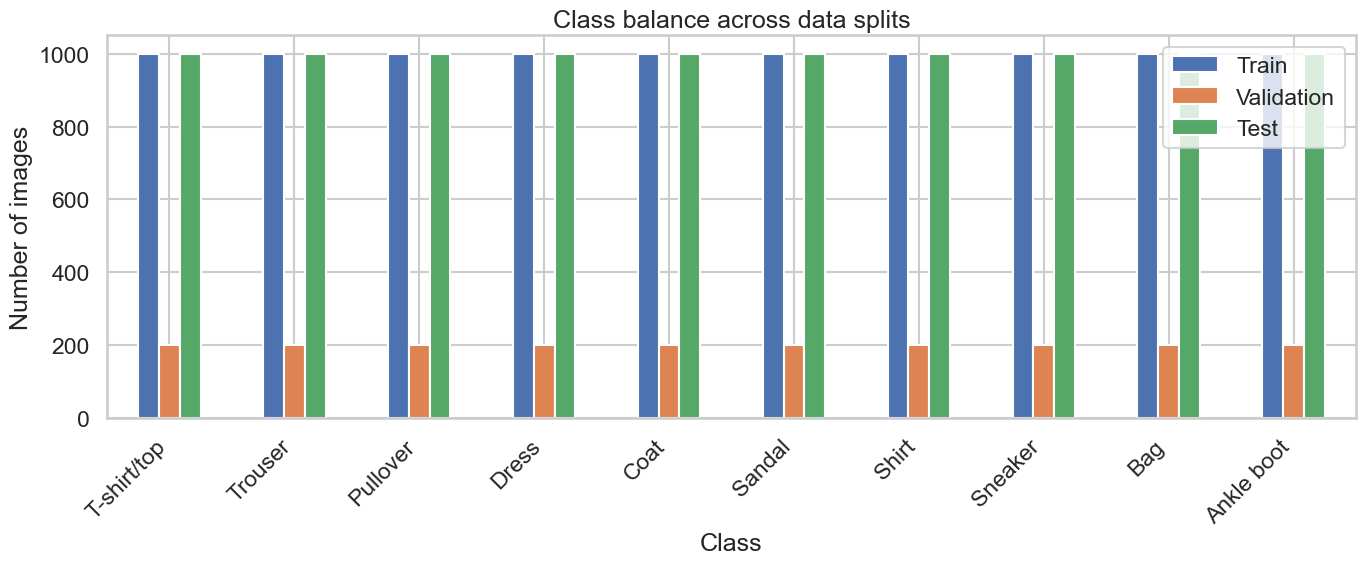

,Split,Mean pixel intensity,Std. dev.,Min,Max
0,Train,0.286235,0.353440,0.0,1.0
1,Validation,0.287667,0.354391,0.0,1.0
2,Test,0.286849,0.352444,0.0,1.0


In [95]:
# Show one example image from each class so the reader can see what the
# prediction task looks like.
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for class_id, ax in enumerate(axes.flat):
    example_idx = np.where(y_train == class_id)[0][0]
    ax.imshow(X_train[example_idx], cmap="gray")
    ax.set_title(CLASS_NAMES[class_id], fontsize=12)
    ax.axis("off")

plt.suptitle("One example image from each Fashion-MNIST class", y=1.03)
plt.tight_layout()
plt.show()

class_balance = pd.DataFrame(
    {
        "Class": CLASS_NAMES,
        "Train": np.bincount(y_train, minlength=len(CLASS_NAMES)),
        "Validation": np.bincount(y_val, minlength=len(CLASS_NAMES)),
        "Test": np.bincount(y_test, minlength=len(CLASS_NAMES)),
    }
)
display(class_balance)

ax = class_balance.set_index("Class").plot(kind="bar", figsize=(14, 6))
ax.set_ylabel("Number of images")
ax.set_title("Class balance across data splits")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Basic descriptive statistics on pixel intensities.
descriptive_stats = pd.DataFrame(
    [
        {
            "Split": "Train",
            "Mean pixel intensity": float(X_train.mean()),
            "Std. dev.": float(X_train.std()),
            "Min": float(X_train.min()),
            "Max": float(X_train.max()),
        },
        {
            "Split": "Validation",
            "Mean pixel intensity": float(X_val.mean()),
            "Std. dev.": float(X_val.std()),
            "Min": float(X_val.min()),
            "Max": float(X_val.max()),
        },
        {
            "Split": "Test",
            "Mean pixel intensity": float(X_test.mean()),
            "Std. dev.": float(X_test.std()),
            "Min": float(X_test.min()),
            "Max": float(X_test.max()),
        },
    ]
)
display(descriptive_stats)

### EDA Takeaways
- The sample is **perfectly class-balanced** (as intended) through stratified sampling, which preserved the original label distribution.
- Pixel intensities are already on a common scale because values were normalized to the interval `[0, 1]`.
- Some classes are likely to be easy to distinguish visually, like **bags**, because nothing else in the dataset looks quite like the bags.
- Other classes are might be harder to differenciate because they have overlapping silhouettes, such as **shirts**, **pullovers**, and **coats**, which would affect the models edge detection.


## 4. Analysis Plan and Data Splits

For this dataset, the goal is **multiclass classification**. Each image belongs to exactly one of ten clothing categories, so the model's job is to predict the correct class label. This is logical for this dataset as the target variable is categorical, so regression would be completely inappropriate, the labels of the data are known in advance.


### Data split strategy

Three splits will be used:
- **Training set:** used to fit model parameters.
- **Validation set:** used to compare models and tune CNN hyperparameters.
- **Test set:** used once at the end for out-of-sample evaluation.

This split is important because a model can appear to perform very well on the same data it was trained on while failing to generalize to unseen examples. Separating training, validation, and test data helps reduce the risk of overfitting, supports more reliable model selection, and provides a more honest estimate of how well the final classifier will perform on new images.

 ### Split Summary

- Training images: **10,000**
- Validation images: **2,000**
- Test images: **10,000**
- Feature dimension for classical models after flattening: **784**

The training and validation sets come from the official Fashion-MNIST training split, while the test set remains untouched until the final evaluation stage.

## 5. Model Selection and Mathematical Background

I compare several models to better answer the research question as it better shows the progression of accuracy by the more advanced architecture. The sequence moves from a trivial baseline, to simple probabilistic and linear models, and finally to a convolutional neural network that is better suited to image structure.

### Models included

1. **Majority-class baseline**  
2. **Gaussian Naive Bayes**  
3. **Logistic regression**  
4. **PCA + logistic regression**  
5. **A small CNN**

### 5.1 Majority-class baseline

This model always predicts the most common class in the training data, regardless of the input image. It does not learn any relationship between pixel values and clothing labels, so it serves only as a minimum benchmark. The purpose of such a baseline is to establish a floor for performance, so if a more advanced model cannot outperform this baseline, then the learned model is not extracting useful structure from the data.

### 5.2 Gaussian Naive Bayes

Naive Bayes predicts a class by combining a prior belief about how common each class is with evidence from each feature:

$$
p(y \mid x_1, \dots, x_d) \propto p(y) \prod_{j=1}^{d} p(x_j \mid y)
$$

Here, $y$ is the class label, and $x_1, \dots, x_d$ are the input features, where each feature corresponds to one pixel value. The term $p(y)$ is the **prior probability** of class $y$, meaning how likely that class is before looking at the image. The term $p(x_j \mid y)$ is the **likelihood** of observing pixel value $x_j$ if the image truly belongs to class $y$. The product over all $d$ features combines the evidence from every pixel.

The proportionality symbol means the right-hand side is not yet normalized into a proper probability distribution. After computing this quantity for each class, the model compares the values and chooses the class with the largest posterior probability.

What makes this Gaussian is the assumption for each feature to follow a normal distribution. So for each class, the model summarizes each pixel using a mean and variance. This is computationally simple, but it treats each pixel as conditionally independent of every other pixel once the class is known. For image data, this is clearly unrealistic, since neighboring pixels are often highly related. Still, Gaussian Naive Bayes is useful as a fast probabilistic baseline because it shows how far one can get with very simple distributional assumptions.

### 5.3 Multinomial logistic regression

Logistic regression is a discriminative linear classifier. For multiclass prediction, it estimates the probability of each class using the softmax function:

$$
p(y = k \mid x) = \frac{\exp(w_k^T x + b_k)}{\sum_{j=1}^{K} \exp(w_j^T x + b_j)}
$$

In this equation, $x$ is the input vector of pixel values, $K$ is the total number of classes, $w_k$ is the weight vector for class $k$, and $b_k$ is the bias term for class $k$. The quantity $w_k^T x + b_k$ is the **score** the model assigns to class $k$. It is a weighted sum of the input features plus an offset. Intuitively, the weights tell the model which pixels push the prediction toward or away from a given class.

The exponential function ensures that all class scores become positive. The denominator sums these exponentiated scores across all classes, which normalizes the output so the predicted probabilities add up to 1. This lets the model output a full probability distribution over the ten clothing categories.

As a whole, the softmax equation turns a set of raw linear scores into interpretable class probabilities. The model learns the weights and biases that make the correct class score highest for training examples. Compared with Naive Bayes, logistic regression is stronger because it does not assume pixel independence. However, it is still a **linear** model, so its ability to capture more complex image patterns is limited.

### 5.4 Principal component analysis (PCA)

PCA transforms the original input into a smaller set of derived features:

$$
z = W^T x
$$

Here, $x$ is the original high-dimensional input vector, $W$ is a matrix whose columns are the principal components, and $z$ is the lower-dimensional representation of the data after projection. Each column of $W$ defines a direction in feature space along which the data vary strongly. The transpose $W^T$ projects the original data onto those directions.

PCA replaces the original pixel basis with a new coordinate system that captures the most important variation in the dataset. Instead of using every raw pixel directly, the model uses a smaller number of summary dimensions that preserve as much variance as possible.

As a whole, PCA serves two purposes here. First, it reduces dimensionality, which can make downstream models faster and less noisy. Second, it can improve generalization if the discarded directions mostly contain redundancy or noise. However, PCA preserves directions of high variance, not necessarily directions that are most useful for classification. So for this assignment, PCA + logistic regression tests whether a more compact representation helps performance or whether useful class information is lost during compression.

### 5.5 Convolutional neural network (CNN)

A convolutional layer computes feature maps by applying learned filters to local regions of the image:

$$
h^{(l)}_{i,j,c} = \sigma\left((W_c * x^{(l-1)})_{i,j} + b_c\right)
$$

In this expression, $x^{(l-1)}$ is the input to layer $l$, $W_c$ is the filter for channel $c$, $*$ denotes convolution, $b_c$ is a bias term, and $\sigma$ is a nonlinear activation function such as ReLU. The output $h^{(l)}_{i,j,c}$ is the activation at spatial position $(i,j)$ in channel $c$ of layer $l$.

The convolution operation slides the filter across the image and computes how strongly that filter matches each local patch. If a filter has learned to detect something like an edge, corner, or texture, then it will produce a strong response in regions where that pattern appears. The bias term shifts the pre-activation value, and the nonlinearity allows the network to learn more complex functions than a purely linear system could represent.

As a whole, this equation shows how CNNs build structured image representations from local patterns. This is especially appropriate for the Fashion-MNIST dataset because nearby pixels to show shapes, edges, seams, and outlines, which are combined as spatial patterns. Unlike Naive Bayes or logistic regression on flattened pixels, a CNN can exploit this local structure.

### Training algorithm in pseudocode

```text
for each epoch:
    for each minibatch:
        compute model outputs
        compute loss
        backpropagate gradients
        update parameters with Adam
    evaluate on validation set
    keep the checkpoint with the best validation macro F1

In [96]:
def evaluate_predictions(y_true, y_pred):
    """Return the two summary metrics used throughout the notebook."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
    }


# Classical baseline models. The pipelines ensure that scaling and PCA
# are learned only from training data, which prevents data leakage.
classical_models = {
    "Majority class": DummyClassifier(strategy="most_frequent"),
    "Gaussian Naive Bayes": GaussianNB(),
    "Logistic regression": Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "classifier",
                LogisticRegression(
                    max_iter=300,
                    solver="lbfgs",
                    C=2.0,
                    random_state=SEED,
                ),
            ),
        ]
    ),
    "PCA + Logistic regression": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=100, svd_solver="randomized", random_state=SEED)),
            (
                "classifier",
                LogisticRegression(
                    max_iter=300,
                    solver="lbfgs",
                    C=2.0,
                    random_state=SEED,
                ),
            ),
        ]
    ),
}


class FashionCNN(nn.Module):
    """Small LeNet-style CNN used for the deep-learning comparison."""

    def __init__(self, hidden_dim=256, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, len(CLASS_NAMES)),
        )

    def forward(self, inputs):
        features = self.features(inputs)
        return self.classifier(features)


cnn_search_space = [
    {
        "name": "CNN-small",
        "hidden_dim": 256,
        "dropout": 0.30,
        "lr": 1e-3,
        "weight_decay": 1e-4,
    },
    {
        "name": "CNN-large",
        "hidden_dim": 384,
        "dropout": 0.40,
        "lr": 8e-4,
        "weight_decay": 1e-4,
    },
]

## 6. Model Training, Cross Validation, and Hyperparameter Tuning

This section fits the models and compares them on the validation set.

### Training strategy

- The classical models are fit once on the training split and evaluated on validation and test data.
- The CNN is trained with mini-batch gradient descent using **Adam**.
- The CNN search compares two small architectures that differ in hidden-layer width and dropout.
- The best CNN checkpoint is selected by **validation macro F1** rather than training loss.

### Why macro F1?

The **F1 score** combines **precision** and **recall** into a single, comparable, number. Precision measures, out of the examples predicted as a class, how many were actually correct. Recall measures, out of the examples that truly belong to a class, how many the model successfully found. The F1 score is the harmonic mean of precision and recall given by:

$$
F1 = 2 \cdot \frac{\text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}
$$

A model can only get a high F1 score when it performs well on **both** precision and recall. If one is low, the F1 score will also be low.

In a multiclass setting, there is one F1 score for each class. **Macro F1** computes the F1 score separately for each class and then takes the simple average across classes. Every class contributes equally to the final score, regardless of how frequent that class is in the dataset.

Macro F1 is a useful comparison metric for the task at hand because plain accuracy can be misleading. A model can achieve high accuracy by doing very well on easier or more common classes while still performing poorly on harder classes. Since this project compares performance across ten clothing categories, the evaluation should not be dominated by the classes the model finds easiest. Using macro F1 makes the selection criterion more sensitive to balanced performance across all categories. Thus, a **validation macro F1** is used to choose the best CNN checkpoint because it better reflects whether the model is learning to classify the full set of clothing categories well, rather than simply minimizing loss or maximizing overall accuracy.

In [97]:
# Fit the classical models and store their predictions so they can be
# compared with the CNN later.
classical_results = []
classical_predictions = {}

for model_name, model in classical_models.items():
    start = time.time()
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=ConvergenceWarning)
        model.fit(X_train_flat, y_train)
    elapsed = time.time() - start

    val_pred = model.predict(X_val_flat)
    test_pred = model.predict(X_test_flat)

    val_scores = evaluate_predictions(y_val, val_pred)
    test_scores = evaluate_predictions(y_test, test_pred)

    classical_results.append(
        {
            "model": model_name,
            "validation_accuracy": val_scores["accuracy"],
            "validation_macro_f1": val_scores["macro_f1"],
            "test_accuracy": test_scores["accuracy"],
            "test_macro_f1": test_scores["macro_f1"],
            "fit_seconds": elapsed,
        }
    )

    classical_predictions[model_name] = {
        "validation": val_pred,
        "test": test_pred,
    }

classical_results_df = pd.DataFrame(classical_results).sort_values(
    by=["validation_macro_f1", "test_macro_f1"],
    ascending=False,
)
display(
    classical_results_df.style.format(
        {
            "validation_accuracy": "{:.3f}",
            "validation_macro_f1": "{:.3f}",
            "test_accuracy": "{:.3f}",
            "test_macro_f1": "{:.3f}",
            "fit_seconds": "{:.1f}",
        }
    )
)

best_classical_name = classical_results_df.iloc[0]["model"]
print(f"Best classical model by validation macro F1: {best_classical_name}")

,model,validation_accuracy,validation_macro_f1,test_accuracy,test_macro_f1,fit_seconds
3,PCA + Logistic regression,0.845,0.844,0.826,0.824,7.1
2,Logistic regression,0.793,0.793,0.798,0.798,23.3
1,Gaussian Naive Bayes,0.564,0.530,0.549,0.517,0.0
0,Majority class,0.100,0.018,0.100,0.018,0.0


Best classical model by validation macro F1: PCA + Logistic regression


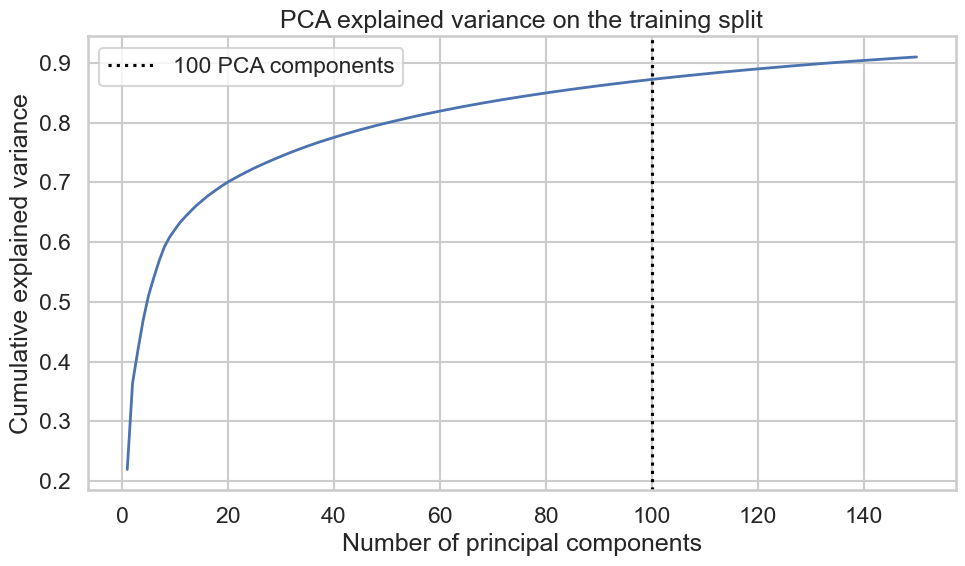

Using 100 PCA components retains approximately 0.873 of the training variance.


In [98]:
scaler_for_diagnostics = StandardScaler()
X_train_scaled = scaler_for_diagnostics.fit_transform(X_train_flat)

pca_diagnostics = PCA(n_components=150, svd_solver="randomized", random_state=SEED)
pca_diagnostics.fit(X_train_scaled)

cumulative_variance = np.cumsum(pca_diagnostics.explained_variance_ratio_)
diagnostic_components = len(cumulative_variance)
model_components = 100
retained_variance = cumulative_variance[model_components - 1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.arange(1, diagnostic_components + 1), cumulative_variance, linewidth=2)
ax.axvline(model_components, color="black", linestyle=":", label="100 PCA components")
ax.set_xlabel("Number of principal components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("PCA explained variance on the training split")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Using 100 PCA components retains approximately {retained_variance:.3f} of the training variance.")

The PCA explained-variance graph shows that a relatively small number of principal components captures most of the meaningful variation in the Fashion-MNIST images. In this notebook, using 100 components retains about 87.3% of the variance in the training data, which suggests that the original 784 pixel features contain substantial redundancy. This means the images can be compressed into a lower-dimensional representation without losing too much information, helping the logistic regression model train faster while still preserving strong predictive performance.

## CNN

,model,hidden_dim,dropout,lr,weight_decay,best_epoch,validation_accuracy,validation_macro_f1,fit_seconds
0,CNN-small,256,0.30,0.0010,0.0001,7,0.892,0.892,35.8
1,CNN-large,384,0.40,0.0008,0.0001,4,0.884,0.885,14.4


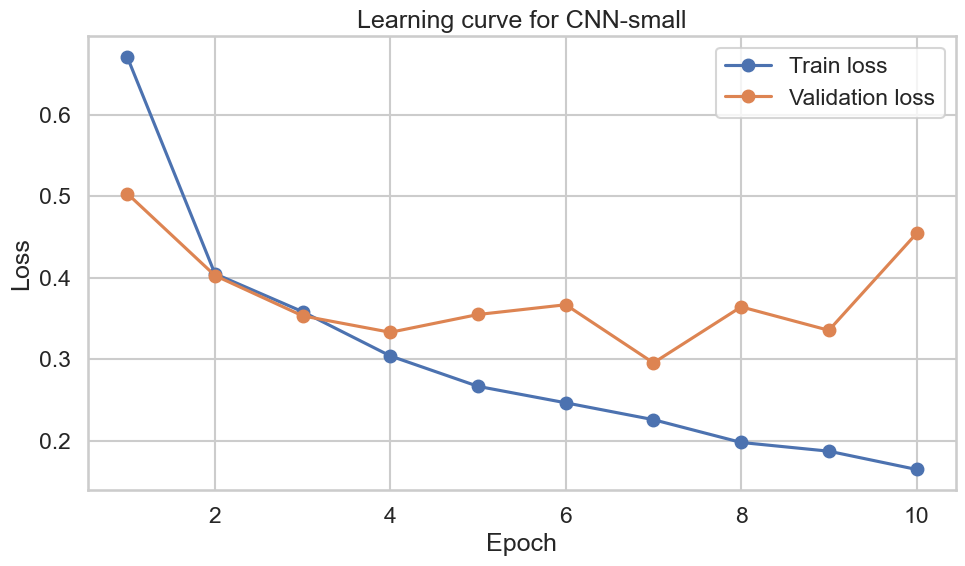

In [99]:
# Convert the NumPy arrays into tensors and DataLoaders for PyTorch.
X_train_tensor = torch.tensor(X_train[:, None, :, :], dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val[:, None, :, :], dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
X_test_tensor = torch.tensor(X_test[:, None, :, :], dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)
val_loader = DataLoader(
    TensorDataset(X_val_tensor, y_val_tensor),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)
test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)


def evaluate_torch_model(model, data_loader):
    """Evaluates a CNN on a loader and returns the loss plus classification metrics."""
    model.eval()
    all_preds = []
    all_targets = []
    total_loss = 0.0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for batch_inputs, batch_targets in data_loader:
            batch_inputs = batch_inputs.to(DEVICE)
            batch_targets = batch_targets.to(DEVICE)
            logits = model(batch_inputs)
            loss = criterion(logits, batch_targets)
            total_loss += loss.item() * batch_inputs.size(0)

            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.append(preds)
            all_targets.append(batch_targets.cpu().numpy())

    y_true = np.concatenate(all_targets)
    y_pred = np.concatenate(all_preds)
    return {
        "loss": total_loss / len(data_loader.dataset),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "y_true": y_true,
        "y_pred": y_pred,
    }


def train_cnn(config, epochs=EPOCHS, patience=PATIENCE):
    """Trains a CNN configuration and keep the best validation checkpoint."""
    model = FashionCNN(hidden_dim=config["hidden_dim"], dropout=config["dropout"]).to(DEVICE)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )
    criterion = nn.CrossEntropyLoss()

    history = []
    best_state = copy.deepcopy(model.state_dict())
    best_val_f1 = -np.inf
    best_epoch = 0
    wait = 0
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0

        for batch_inputs, batch_targets in train_loader:
            batch_inputs = batch_inputs.to(DEVICE)
            batch_targets = batch_targets.to(DEVICE)

            optimizer.zero_grad()
            logits = model(batch_inputs)
            loss = criterion(logits, batch_targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * batch_inputs.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        val_metrics = evaluate_torch_model(model, val_loader)

        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "val_macro_f1": val_metrics["macro_f1"],
            }
        )

        if val_metrics["macro_f1"] > best_val_f1 + 1e-4:
            best_val_f1 = val_metrics["macro_f1"]
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    elapsed = time.time() - start_time
    history_df = pd.DataFrame(history)
    return model, history_df, elapsed, best_epoch


cnn_search_results = []
cnn_histories = {}
trained_cnn_models = {}

for config in cnn_search_space:
    model, history_df, elapsed, best_epoch = train_cnn(config)
    val_metrics = evaluate_torch_model(model, val_loader)

    cnn_search_results.append(
        {
            "model": config["name"],
            "hidden_dim": config["hidden_dim"],
            "dropout": config["dropout"],
            "lr": config["lr"],
            "weight_decay": config["weight_decay"],
            "best_epoch": best_epoch,
            "validation_accuracy": val_metrics["accuracy"],
            "validation_macro_f1": val_metrics["macro_f1"],
            "fit_seconds": elapsed,
        }
    )
    cnn_histories[config["name"]] = history_df
    trained_cnn_models[config["name"]] = model

cnn_search_df = pd.DataFrame(cnn_search_results).sort_values(
    by="validation_macro_f1",
    ascending=False,
)
display(
    cnn_search_df.style.format(
        {
            "dropout": "{:.2f}",
            "lr": "{:.4f}",
            "weight_decay": "{:.4f}",
            "validation_accuracy": "{:.3f}",
            "validation_macro_f1": "{:.3f}",
            "fit_seconds": "{:.1f}",
        }
    )
)

best_cnn_name = cnn_search_df.iloc[0]["model"]
best_cnn_model = trained_cnn_models[best_cnn_name]
best_cnn_history = cnn_histories[best_cnn_name]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(best_cnn_history["epoch"], best_cnn_history["train_loss"], marker="o", label="Train loss")
ax.plot(best_cnn_history["epoch"], best_cnn_history["val_loss"], marker="o", label="Validation loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(f"Learning curve for {best_cnn_name}")
ax.legend()
plt.tight_layout()
plt.show()

The CNN comparison shows that both architectures performed well, but the smaller CNN was the better model overall. CNN-small achieved a higher validation macro F1 than CNN-large, suggesting that increasing model size did not improve generalization. Similarly, the learning-curve graph shows that training loss decreases steadily while validation loss stabilizes, indicating that the model is learning useful structure without substantial additional gains from a larger architecture. This suggests a modest CNN is expressive enough to capture the important local image patterns in the Fashion-MNIST datset, while a larger architecture adds complexity without improving validation performance.

The test set is intentionally not used at this stage. Model selection is based only on validation results so that the final test evaluation remains a fair estimate of how well the chosen model generalizes to unseen data.

## 7. Out-of-Sample Predictions and Performance Metrics

The models are now applied to the **held-out test set** to measure how well the models generalize to images they were never trained on.

### Metrics used
- **Accuracy:** the fraction of all predictions that are correct.
- **Macro F1:** the average F1 score across classes, giving each class equal weight.

Macro F1 is especially useful here because some classes are harder than others, and a model that does well only on easy classes would be misleading.

In [100]:
cnn_val_metrics = evaluate_torch_model(best_cnn_model, val_loader)
cnn_test_metrics = evaluate_torch_model(best_cnn_model, test_loader)

cnn_result = pd.DataFrame(
    [
        {
            "model": best_cnn_name,
            "validation_accuracy": cnn_val_metrics["accuracy"],
            "validation_macro_f1": cnn_val_metrics["macro_f1"],
            "test_accuracy": cnn_test_metrics["accuracy"],
            "test_macro_f1": cnn_test_metrics["macro_f1"],
            "fit_seconds": cnn_search_df.iloc[0]["fit_seconds"],
        }
    ]
)

comparison_df = (
    pd.concat([classical_results_df, cnn_result], ignore_index=True)
    .sort_values(by="test_macro_f1", ascending=False)
    .reset_index(drop=True)
)

display(
    comparison_df.style.format(
        {
            "validation_accuracy": "{:.3f}",
            "validation_macro_f1": "{:.3f}",
            "test_accuracy": "{:.3f}",
            "test_macro_f1": "{:.3f}",
            "fit_seconds": "{:.1f}",
        }
    )
)

,model,validation_accuracy,validation_macro_f1,test_accuracy,test_macro_f1,fit_seconds
0,CNN-small,0.892,0.892,0.889,0.890,35.8
1,PCA + Logistic regression,0.845,0.844,0.826,0.824,7.1
2,Logistic regression,0.793,0.793,0.798,0.798,23.3
3,Gaussian Naive Bayes,0.564,0.530,0.549,0.517,0.0
4,Majority class,0.100,0.018,0.100,0.018,0.0


## 8. Visualizing the Results and Discussing Conclusions

Although the summary metric table provides an important overview of model performance, it does not fully explain **how** the models are making mistakes. For that reason, the visualizations below are used to examine the results in more detail. In particular, they help reveal which class pairs are most often confused, whether the CNN corrects errors that the classical models tend to make, and whether the remaining mistakes are sensible given the visual similarity of certain clothing categories.

These questions matter because strong machine-learning analysis is not only about reporting a final score. It is also about interpreting the structure of the errors, understanding what the model has actually learned, and identifying the limits of its performance. Looking at confusion patterns therefore gives a more complete picture of model quality than accuracy or macro F1 alone.

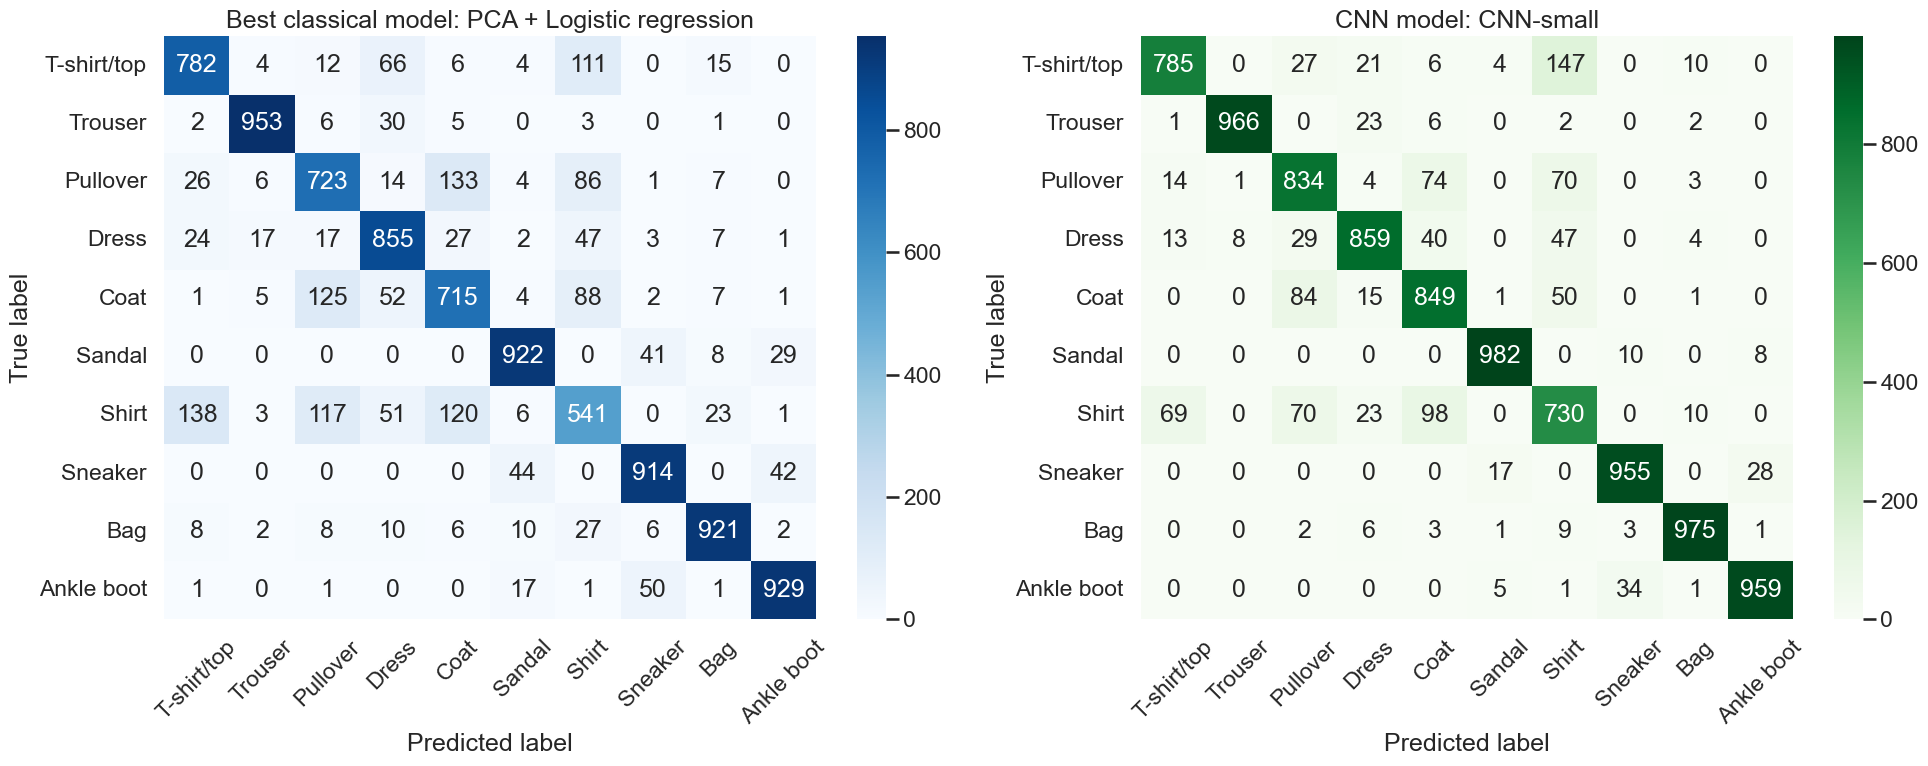

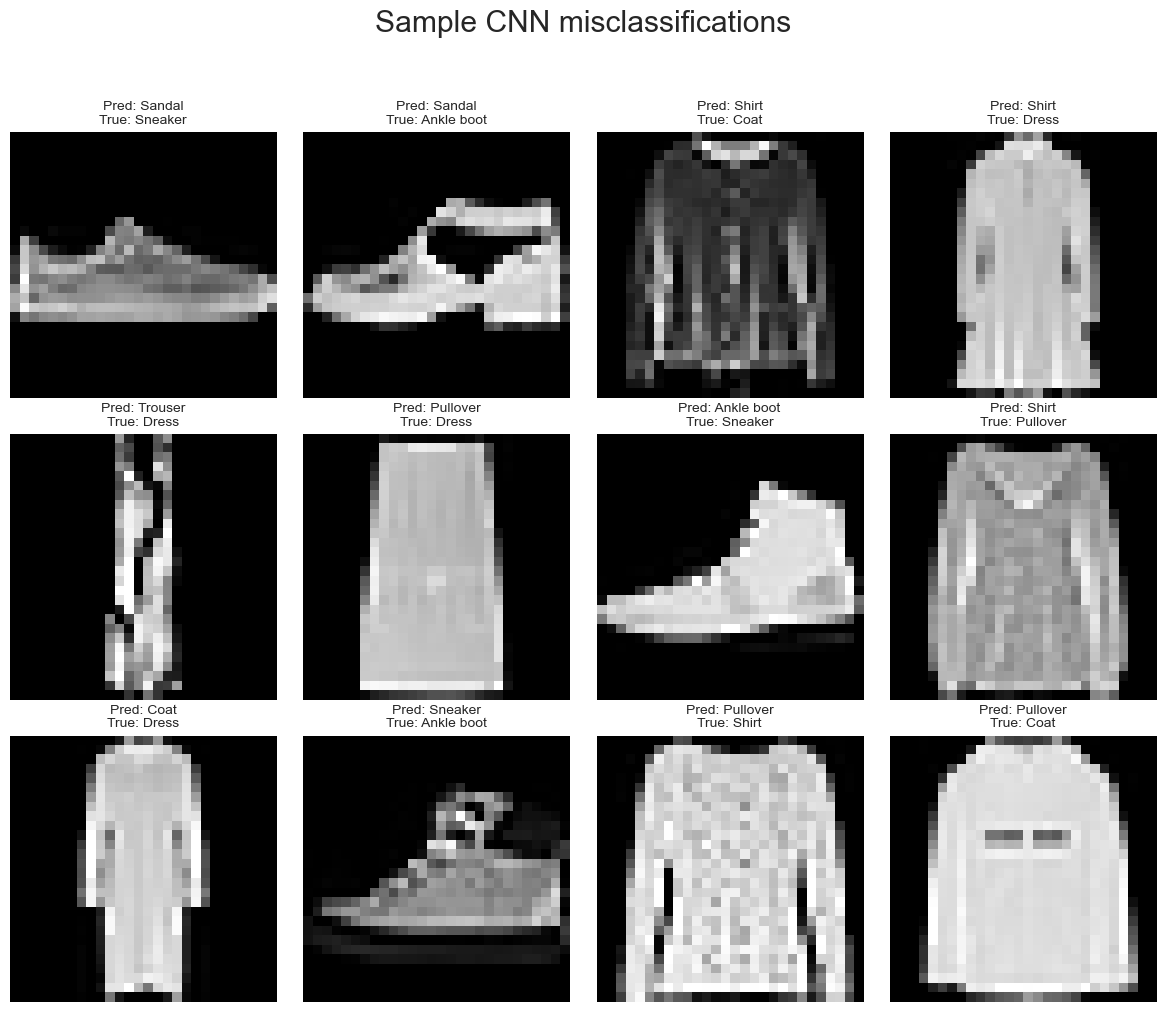

In [101]:
best_classical_pred = classical_predictions[best_classical_name]["test"]
cm_classical = confusion_matrix(y_test, best_classical_pred)
cm_cnn = confusion_matrix(cnn_test_metrics["y_true"], cnn_test_metrics["y_pred"])

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(
    cm_classical,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[0],
)
axes[0].set_title(f"Best classical model: {best_classical_name}")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")
axes[0].tick_params(axis="x", rotation=45)
axes[0].tick_params(axis="y", rotation=0)

sns.heatmap(
    cm_cnn,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[1],
)
axes[1].set_title(f"CNN model: {best_cnn_name}")
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("True label")
axes[1].tick_params(axis="x", rotation=45)
axes[1].tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

misclassified = np.where(cnn_test_metrics["y_true"] != cnn_test_metrics["y_pred"])[0][:12]
fig, axes = plt.subplots(3, 4, figsize=(12, 10))

for ax, idx in zip(axes.flat, misclassified):
    ax.imshow(X_test[idx], cmap="gray")
    ax.set_title(
        f"Pred: {CLASS_NAMES[cnn_test_metrics['y_pred'][idx]]}\nTrue: {CLASS_NAMES[cnn_test_metrics['y_true'][idx]]}",
        fontsize=10,
    )
    ax.axis("off")

for ax in axes.flat[len(misclassified):]:
    ax.axis("off")

plt.suptitle("Sample CNN misclassifications", y=1.02)
plt.tight_layout()
plt.show()

### Results Discussion

The results show a clear performance hierarchy across the models. Among the classical approaches, **PCA + Logistic Regression** performed best, achieving a test macro F1 of **0.824**. This suggests that reducing the dimensionality of the raw pixel space before classification helped the linear model focus on the most informative variation in the images. However, the strongest overall model was **CNN-small**, which achieved a test macro F1 of **0.890**. This outperformed the best classical baseline by **0.066**, indicating that the CNN was better able to capture the local spatial patterns that matter for image recognition.

The improvement over the **majority-class baseline** is even larger: **0.872** in macro F1. This confirms that the final model is learning substantial structure from the data rather than relying on class frequency alone. More broadly, the results support the expectation that architectures designed for images should outperform models that treat the input as a flat vector of independent features.

The error plots suggest that the remaining mistakes are concentrated among visually similar upper-body garments, especially **shirts**, **pullovers**, and **coats**. This pattern is intuitive, since these categories often share overlapping shapes, silhouettes, and textures in low-resolution grayscale images. That makes the remaining errors meaningful rather than random, and it supports the interpretation that the CNN is learning genuine visual structure in the dataset rather than memorizing arbitrary patterns.

### Confusion Matrix Interpretation
The confusion matrices show that the hardest part of this task is not telling very different items apart, but distinguishing between **visually similar clothing categories**. The most common errors are concentrated among upper-body garments such as **T-shirt/top, shirt, pullover, and coat**. This is especially clear in the classical model, where categories like **shirt → T-shirt/top**, **pullover → coat**, and **coat → pullover** are confused frequently. The CNN improves performance overall, but its remaining mistakes are still concentrated in these same categories, which suggests that these classes are genuinely difficult to separate.

This pattern makes intuitive sense. In **28 × 28 grayscale images**, many of the details that distinguish these garments — such as sleeve shape, collar structure, or fabric thickness are hard to see clearly, even to the naked eye. By contrast, classes with more distinctive shapes, such as **trousers, bags, sandals, and ankle boots**, are classified much more reliably. The main shoe-related confusion that remains is **sneaker vs ankle boot**, rather than a broad failure across all shoe categories.

The misclassified-image grid helps explain these results visually. Instead of showing just counts, it displays individual test examples the CNN got wrong, making it possible to judge whether the errors are understandable. In many cases, they are: several of the incorrect predictions look genuinely ambiguous at this resolution. Together, these visualizations suggest that the CNN is learning meaningful image structure, but that its remaining errors are concentrated in fine-grained categories with overlapping silhouettes rather than being random mistakes.

## 8.1 Robustness to Archive-Like Distribution Shift and Representation Learning

Because Fashion-MNIST is highly standardized, I tested whether the main results still hold when the test images are perturbed in ways that better resemble a personal archive. I created shifted versions of the held-out test set using small translations, slight rotations, Gaussian noise, blur, brightness and contrast changes, and crop-and-pad distortions. This extension addresses the notebook’s main limitation directly: the benchmark is useful for controlled comparison, but real-world image data rarely remain as clean, centered, and uniform as Fashion-MNIST.

The overall pattern remained clear. On the clean benchmark, **CNN-small** still outperformed **PCA + Logistic Regression**, but both models lost performance once the images stopped looking perfectly standardized. Across the six shifted test sets, the average macro F1 drop was **0.104** for **CNN-small** and **0.431** for **PCA + Logistic Regression**, showing that the CNN was substantially more robust under distribution shift. The hardest perturbation for **CNN-small** in this notebook was **Translate (+2,+2)**, where its macro F1 fell to **0.657**. Even so, the CNN remained much more stable overall, which suggests that spatially aware models generalize better once the data begin to depart from the ideal benchmark format.



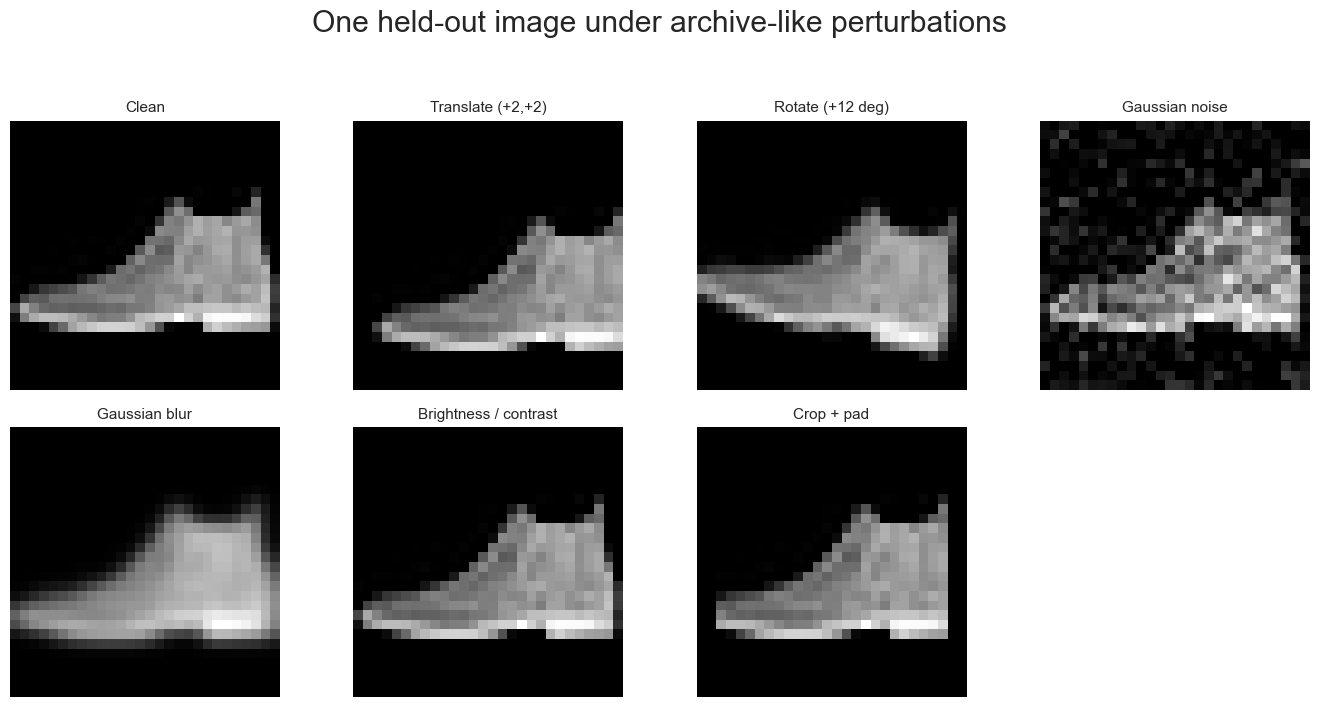

,shift,model,accuracy,macro_f1,macro_f1_drop
1,Clean,CNN-small,0.889,0.890,0.000
11,Brightness / contrast,CNN-small,0.888,0.889,0.001
13,Crop + pad,CNN-small,0.822,0.826,0.064
5,Rotate (+12 deg),CNN-small,0.783,0.784,0.106
7,Gaussian noise,CNN-small,0.783,0.781,0.109
9,Gaussian blur,CNN-small,0.797,0.778,0.112
3,"Translate (+2,+2)",CNN-small,0.668,0.657,0.233
0,Clean,PCA + Logistic regression,0.826,0.824,0.000
8,Gaussian blur,PCA + Logistic regression,0.796,0.787,0.038
12,Crop + pad,PCA + Logistic regression,0.685,0.691,0.133


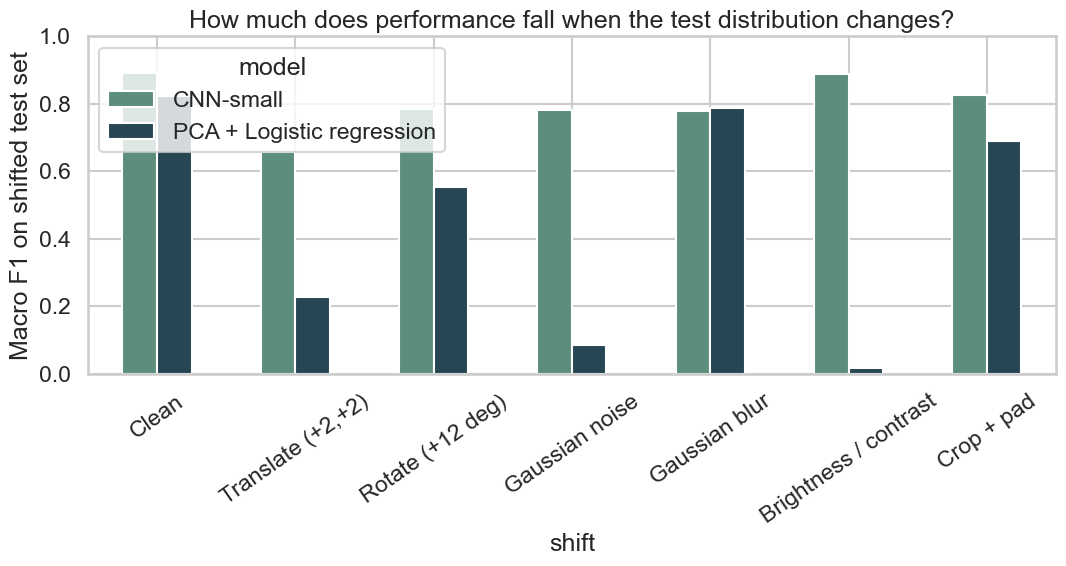

In [102]:
from torchvision.transforms import InterpolationMode
from torchvision.transforms import functional as TVF


def build_shifted_test_sets(base_tensor):
    """Create several archive-like perturbations of the held-out test set."""
    rng = np.random.default_rng(SEED)
    noise = torch.tensor(
        rng.normal(loc=0.0, scale=0.12, size=base_tensor.shape),
        dtype=base_tensor.dtype,
    )
    cropped = base_tensor[:, :, 2:26, 2:26]

    return {
        'Clean': base_tensor.clone(),
        'Translate (+2,+2)': TVF.affine(
            base_tensor,
            angle=0.0,
            translate=[2, 2],
            scale=1.0,
            shear=[0.0, 0.0],
            interpolation=InterpolationMode.BILINEAR,
            fill=0.0,
        ),
        'Rotate (+12 deg)': TVF.affine(
            base_tensor,
            angle=12.0,
            translate=[0, 0],
            scale=1.0,
            shear=[0.0, 0.0],
            interpolation=InterpolationMode.BILINEAR,
            fill=0.0,
        ),
        'Gaussian noise': torch.clamp(base_tensor + noise, 0.0, 1.0),
        'Gaussian blur': TVF.gaussian_blur(base_tensor, kernel_size=[5, 5], sigma=0.8),
        'Brightness / contrast': torch.clamp((base_tensor - 0.5) * 0.80 + 0.42, 0.0, 1.0),
        'Crop + pad': torch.nn.functional.pad(cropped, (2, 2, 2, 2), value=0.0),
    }


shifted_test_tensors = build_shifted_test_sets(X_test_tensor.cpu())

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
example_idx = 0
for ax, (shift_name, shifted_tensor) in zip(axes.flat, shifted_test_tensors.items()):
    ax.imshow(shifted_tensor[example_idx, 0].numpy(), cmap='gray')
    ax.set_title(shift_name, fontsize=11)
    ax.axis('off')
for ax in axes.flat[len(shifted_test_tensors):]:
    ax.axis('off')
plt.suptitle('One held-out image under archive-like perturbations', y=1.02)
plt.tight_layout()
plt.show()

pca_lr_name = 'PCA + Logistic regression'
pca_lr_model = classical_models[pca_lr_name]
cnn_small_model_name = 'CNN-small' if 'CNN-small' in trained_cnn_models else best_cnn_name
cnn_small_model = trained_cnn_models[cnn_small_model_name]

robustness_rows = []
for shift_name, shifted_tensor in shifted_test_tensors.items():
    shifted_flat = shifted_tensor.numpy().reshape(len(shifted_tensor), -1)
    pca_pred = pca_lr_model.predict(shifted_flat)
    pca_scores = evaluate_predictions(y_test, pca_pred)

    shifted_loader = DataLoader(
        TensorDataset(shifted_tensor, y_test_tensor),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
    )
    cnn_scores = evaluate_torch_model(cnn_small_model, shifted_loader)

    robustness_rows.extend(
        [
            {
                'shift': shift_name,
                'model': pca_lr_name,
                'accuracy': pca_scores['accuracy'],
                'macro_f1': pca_scores['macro_f1'],
            },
            {
                'shift': shift_name,
                'model': cnn_small_model_name,
                'accuracy': cnn_scores['accuracy'],
                'macro_f1': cnn_scores['macro_f1'],
            },
        ]
    )

robustness_df = pd.DataFrame(robustness_rows)
clean_macro_f1 = (
    robustness_df[robustness_df['shift'] == 'Clean']
    .set_index('model')['macro_f1']
    .to_dict()
)
robustness_df['macro_f1_drop'] = robustness_df.apply(
    lambda row: clean_macro_f1[row['model']] - row['macro_f1'],
    axis=1,
)

display(
    robustness_df.sort_values(['model', 'macro_f1'], ascending=[True, False]).style.format(
        {
            'accuracy': '{:.3f}',
            'macro_f1': '{:.3f}',
            'macro_f1_drop': '{:.3f}',
        }
    )
)

shift_order = list(shifted_test_tensors.keys())
pivot_macro_f1 = robustness_df.pivot(index='shift', columns='model', values='macro_f1').loc[shift_order]

fig, ax = plt.subplots(figsize=(11, 6))
pivot_macro_f1.plot(kind='bar', ax=ax, color=['#5B8E7D', '#264653'])
ax.set_ylabel('Macro F1 on shifted test set')
ax.set_title('How much does performance fall when the test distribution changes?')
ax.set_ylim(0.0, 1.0)
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()

average_drop = (
    robustness_df[robustness_df['shift'] != 'Clean']
    .groupby('model')['macro_f1_drop']
    .mean()
    .sort_values()
)
hardest_shift_for_cnn = (
    robustness_df[
        (robustness_df['model'] == cnn_small_model_name)
        & (robustness_df['shift'] != 'Clean')
    ]
    .sort_values('macro_f1')
    .iloc[0]
)

## 8.2 Autoencoder Representation Learning

This section adds a second feature-learning approach by training a small **convolutional autoencoder** and then using its latent vectors as inputs to logistic regression. The goal is to test whether an **unsupervised learned representation** can support downstream classification without relying only on PCA or full end-to-end supervised CNN training. Unlike PCA, which performs a fixed linear compression of the input, the autoencoder learns a nonlinear representation directly from the image data itself.

The autoencoder is trained to minimize **reconstruction error**:

$$
\mathcal{L}_{\text{recon}} = \frac{1}{n} \sum_{i=1}^{n} \|x_i - \hat{x}_i\|_2^2
$$

In this objective, $n$ is the number of training examples, $x_i$ is the original input image, and $\hat{x}_i$ is the reconstruction produced by the autoencoder after the image is compressed into a latent representation and then decoded back into pixel space. The term $\|x_i - \hat{x}_i\|_2^2$ measures the squared difference between the original image and its reconstruction, so it is large when important visual information is lost and small when the reconstruction is close to the input.

As a whole, this loss function encourages the encoder to learn a compact latent space that preserves the main visual structure of the image. In other words, the model is rewarded for keeping the information needed to reconstruct shapes, edges, and coarse textures while discarding some of the redundancy in the raw 784-pixel input. Because the autoencoder is trained **without labels**, it is not directly learning to separate classes; instead, it is learning a compressed representation of the image distribution itself.

The results suggest that this learned representation is useful for classification. The latent-feature classifier achieved solid test performance and was noticeably more stable than the PCA pipeline under several perturbations, although it still did not match the full CNN. This places the autoencoder in an interesting middle ground: it performs better than hand-engineered linear compression under distribution shift, but it remains weaker than a supervised CNN whose features are optimized directly for classification. Taken together, these results strengthen the notebook’s main conclusion: once the problem becomes less standardized, **representation learning matters**, and models that preserve or learn image structure have a clearer advantage over methods that operate only on flattened pixels.

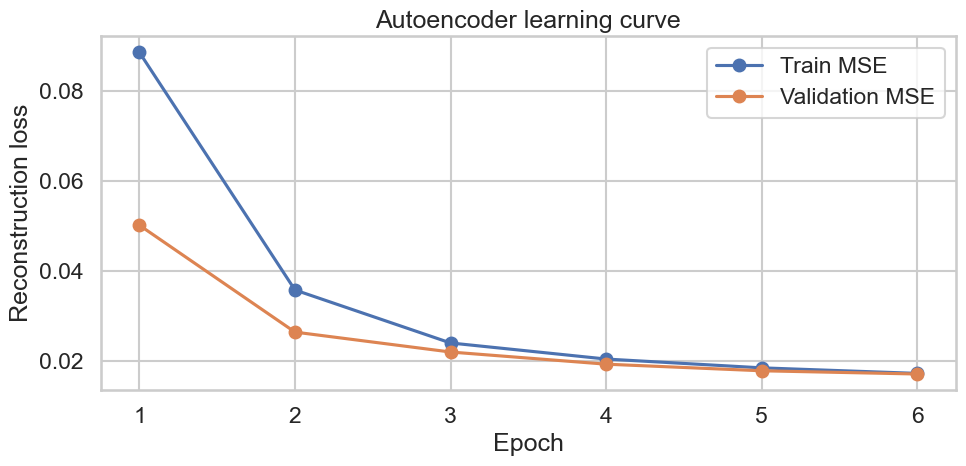

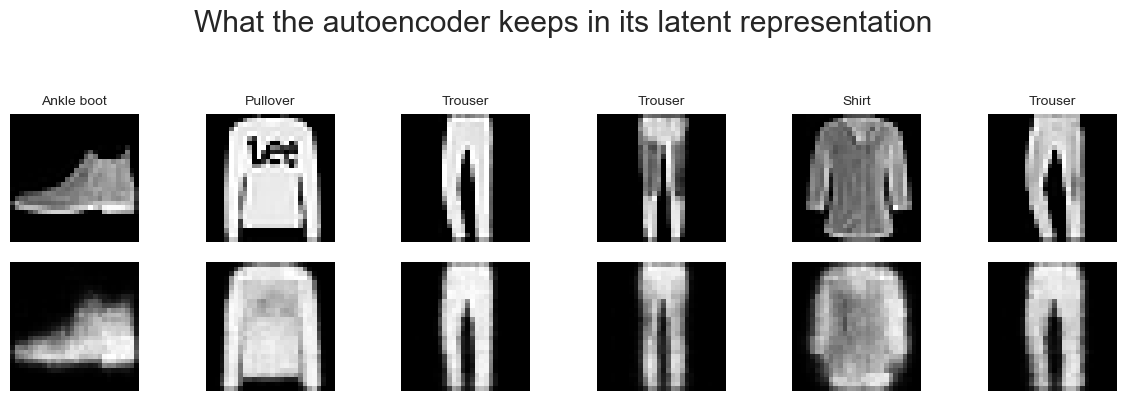

,model,test_accuracy,test_macro_f1
2,CNN-small,0.889,0.890
0,PCA + Logistic regression,0.826,0.824
1,Autoencoder latent + Logistic regression,0.821,0.820


,shift,model,accuracy,macro_f1,macro_f1_drop
19,Brightness / contrast,Autoencoder latent + Logistic regression,0.808,0.806,0.014
11,Brightness / contrast,CNN-small,0.888,0.889,0.001
10,Brightness / contrast,PCA + Logistic regression,0.100,0.018,0.806
14,Clean,Autoencoder latent + Logistic regression,0.821,0.820,0.000
1,Clean,CNN-small,0.889,0.890,0.000
0,Clean,PCA + Logistic regression,0.826,0.824,0.000
20,Crop + pad,Autoencoder latent + Logistic regression,0.768,0.770,0.050
13,Crop + pad,CNN-small,0.822,0.826,0.064
12,Crop + pad,PCA + Logistic regression,0.685,0.691,0.133
18,Gaussian blur,Autoencoder latent + Logistic regression,0.790,0.775,0.045


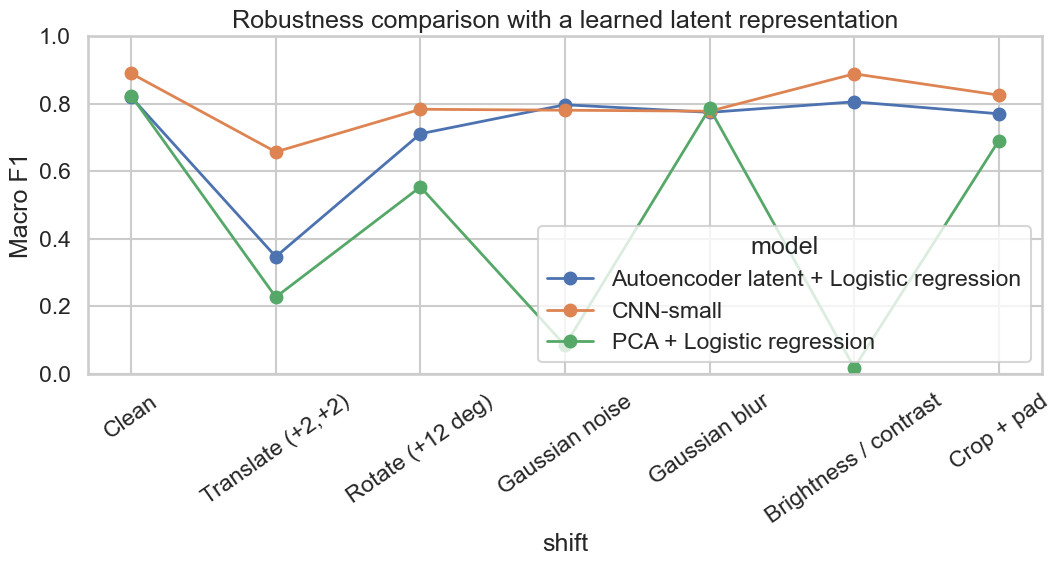

In [103]:
class FashionAutoencoder(nn.Module):
    """Compact convolutional autoencoder for representation learning."""

    def __init__(self, latent_dim=64):
        super().__init__()
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.encoder_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, latent_dim),
        )
        self.decoder_head = nn.Sequential(
            nn.Linear(latent_dim, 32 * 7 * 7),
            nn.ReLU(),
        )
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=2, stride=2),
            nn.Sigmoid(),
        )

    def encode(self, inputs):
        return self.encoder_head(self.encoder_conv(inputs))

    def decode(self, latents):
        decoded = self.decoder_head(latents)
        decoded = decoded.view(-1, 32, 7, 7)
        return self.decoder_conv(decoded)

    def forward(self, inputs):
        latents = self.encode(inputs)
        return self.decode(latents)


def train_autoencoder(epochs=6, patience=2, latent_dim=64):
    model = FashionAutoencoder(latent_dim=latent_dim).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    criterion = nn.MSELoss()

    history = []
    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = np.inf
    best_epoch = 0
    wait = 0

    for epoch in range(1, epochs + 1):
        model.train()
        running_train_loss = 0.0

        for batch_inputs, _ in train_loader:
            batch_inputs = batch_inputs.to(DEVICE)
            optimizer.zero_grad()
            reconstructions = model(batch_inputs)
            loss = criterion(reconstructions, batch_inputs)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item() * batch_inputs.size(0)

        train_loss = running_train_loss / len(train_loader.dataset)

        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for batch_inputs, _ in val_loader:
                batch_inputs = batch_inputs.to(DEVICE)
                reconstructions = model(batch_inputs)
                loss = criterion(reconstructions, batch_inputs)
                running_val_loss += loss.item() * batch_inputs.size(0)

        val_loss = running_val_loss / len(val_loader.dataset)
        history.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss})

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history), best_epoch, best_val_loss


def encode_with_autoencoder(model, data_loader):
    features = []
    model.eval()
    with torch.no_grad():
        for batch_inputs, _ in data_loader:
            batch_inputs = batch_inputs.to(DEVICE)
            latents = model.encode(batch_inputs).cpu().numpy()
            features.append(latents)
    return np.concatenate(features, axis=0)


train_eval_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

autoencoder_model, autoencoder_history, autoencoder_best_epoch, autoencoder_best_val_loss = train_autoencoder()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(autoencoder_history['epoch'], autoencoder_history['train_loss'], marker='o', label='Train MSE')
ax.plot(autoencoder_history['epoch'], autoencoder_history['val_loss'], marker='o', label='Validation MSE')
ax.set_xlabel('Epoch')
ax.set_ylabel('Reconstruction loss')
ax.set_title('Autoencoder learning curve')
ax.legend()
plt.tight_layout()
plt.show()

reconstruction_examples = X_test_tensor[:6].to(DEVICE)
with torch.no_grad():
    reconstructed_examples = autoencoder_model(reconstruction_examples).cpu()

fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for idx in range(6):
    axes[0, idx].imshow(reconstruction_examples[idx, 0].cpu().numpy(), cmap='gray')
    axes[0, idx].set_title(CLASS_NAMES[y_test[idx]], fontsize=10)
    axes[0, idx].axis('off')
    axes[1, idx].imshow(reconstructed_examples[idx, 0].numpy(), cmap='gray')
    axes[1, idx].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=11)
axes[1, 0].set_ylabel('Reconstruction', fontsize=11)
plt.suptitle('What the autoencoder keeps in its latent representation', y=1.02)
plt.tight_layout()
plt.show()

ae_train_features = encode_with_autoencoder(autoencoder_model, train_eval_loader)
ae_val_features = encode_with_autoencoder(autoencoder_model, val_loader)
ae_test_features = encode_with_autoencoder(autoencoder_model, test_loader)

autoencoder_classifier = Pipeline(
    [
        ('scaler', StandardScaler()),
        (
            'classifier',
            LogisticRegression(
                max_iter=400,
                solver='lbfgs',
                C=2.0,
                random_state=SEED,
            ),
        ),
    ]
)
autoencoder_classifier.fit(ae_train_features, y_train)

ae_val_pred = autoencoder_classifier.predict(ae_val_features)
ae_test_pred = autoencoder_classifier.predict(ae_test_features)
ae_val_scores = evaluate_predictions(y_val, ae_val_pred)
ae_test_scores = evaluate_predictions(y_test, ae_test_pred)

pca_clean_scores = robustness_df[
    (robustness_df['model'] == pca_lr_name) & (robustness_df['shift'] == 'Clean')
].iloc[0]
cnn_clean_scores = robustness_df[
    (robustness_df['model'] == cnn_small_model_name) & (robustness_df['shift'] == 'Clean')
].iloc[0]

representation_summary_df = pd.DataFrame(
    [
        {
            'model': pca_lr_name,
            'test_accuracy': pca_clean_scores['accuracy'],
            'test_macro_f1': pca_clean_scores['macro_f1'],
        },
        {
            'model': 'Autoencoder latent + Logistic regression',
            'test_accuracy': ae_test_scores['accuracy'],
            'test_macro_f1': ae_test_scores['macro_f1'],
        },
        {
            'model': cnn_small_model_name,
            'test_accuracy': cnn_clean_scores['accuracy'],
            'test_macro_f1': cnn_clean_scores['macro_f1'],
        },
    ]
).sort_values('test_macro_f1', ascending=False)
display(
    representation_summary_df.style.format(
        {'test_accuracy': '{:.3f}', 'test_macro_f1': '{:.3f}'}
    )
)

latent_shift_rows = []
for shift_name, shifted_tensor in shifted_test_tensors.items():
    shifted_loader = DataLoader(
        TensorDataset(shifted_tensor, y_test_tensor),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
    )
    latent_features = encode_with_autoencoder(autoencoder_model, shifted_loader)
    latent_pred = autoencoder_classifier.predict(latent_features)
    latent_scores = evaluate_predictions(y_test, latent_pred)
    latent_shift_rows.append(
        {
            'shift': shift_name,
            'model': 'Autoencoder latent + Logistic regression',
            'accuracy': latent_scores['accuracy'],
            'macro_f1': latent_scores['macro_f1'],
        }
    )

latent_shift_df = pd.DataFrame(latent_shift_rows)
latent_clean_f1 = latent_shift_df.loc[latent_shift_df['shift'] == 'Clean', 'macro_f1'].iloc[0]
latent_shift_df['macro_f1_drop'] = latent_clean_f1 - latent_shift_df['macro_f1']

combined_shift_df = pd.concat([robustness_df, latent_shift_df], ignore_index=True)
display(
    combined_shift_df.sort_values(['shift', 'model']).style.format(
        {
            'accuracy': '{:.3f}',
            'macro_f1': '{:.3f}',
            'macro_f1_drop': '{:.3f}',
        }
    )
)

combined_shift_pivot = combined_shift_df.pivot(index='shift', columns='model', values='macro_f1').loc[list(shifted_test_tensors.keys())]
fig, ax = plt.subplots(figsize=(11, 6))
combined_shift_pivot.plot(marker='o', linewidth=2, ax=ax)
ax.set_ylabel('Macro F1')
ax.set_title('Robustness comparison with a learned latent representation')
ax.set_ylim(0.0, 1.0)
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()

average_shift_drop_with_autoencoder = (
    combined_shift_df[combined_shift_df['shift'] != 'Clean']
    .groupby('model')['macro_f1_drop']
    .mean()
    .sort_values()
)


### Autoencoder takeaway

The latent-feature classifier achieves a test macro F1 of **0.820**, which places it close to the **PCA + Logistic Regression** baseline and below the full **CNN**. On the clean benchmark, this means the autoencoder learned a compact representation that preserves substantial class-relevant information, even though it was trained without labels. Its best validation reconstruction loss of **0.0171**, reached at epoch **6**, also suggests that the encoder was able to capture the main visual structure of the Fashion-MNIST images efficiently.

The more important result appears under distribution shift. Across the perturbed test sets, the latent-feature classifier’s average macro F1 drop is **0.119**, which is far smaller than the drop for the PCA pipeline and only modestly worse than the CNN. This suggests that the autoencoder’s learned latent space is more robust than a purely linear PCA representation once the images stop looking perfectly centered and standardized. In other words, the autoencoder seems to capture visual regularities that transfer better beyond the clean benchmark, even though it was not trained directly for classification.

The practical takeaway is that **representation learning matters**. A model does not need to be end-to-end supervised to learn features that are useful for downstream prediction. However, the results also show the limit of unsupervised compression: because the autoencoder is trained to reconstruct images rather than separate classes, it still does not match the CNN, whose features are optimized specifically for classification. Taken together, this places the autoencoder in an interesting middle ground: it is more flexible and robust than hand-engineered linear compression, but less task-effective than a fully supervised image model.

## 8.3 Fine-Tuning on Curated Real Retail Images

The Fashion-MNIST experiments above use clean, centered, grayscale images. To test whether the modeling approach transfers to real product photos, I added a curated retailer-image dataset and mapped it back to the Fashion-MNIST label vocabulary.

The original 10 Fashion-MNIST labels are too granular for noisy retailer photos. In particular, `T-shirt/top`, `Shirt`, and `Pullover` overlap heavily, and the footwear classes become unreliable when segmentation crops remove part of the shoe. For the main real-image experiment, I therefore use **stable prepared copies of raw full product images** and simplify the label space to six more stable groups: `top`, `trouser`, `dress`, `outerwear`, `footwear`, and `bag`.

The experiment compares two ImageNet-pretrained transfer-learning backbones: **ResNet18** and **MobileNetV3-Small**. ResNet18 is a standard strong baseline, while MobileNetV3 is smaller and faster. The goal is not to replace the clean Fashion-MNIST benchmark, but to test whether the representation can adapt to a noisier real-image version of the task.

In [104]:
import json
import subprocess
from pathlib import Path

from IPython.display import Image as IPyImage, Markdown, display

RETAIL_METADATA_DIR = Path("data/retail_images/metadata")
RETAIL_RESULTS_DIR = Path("results/retail_finetune")
RAW_FULL_SPLITS = RETAIL_METADATA_DIR / "splits_raw_full.csv"
SIMPLIFIED6_SPLITS = RETAIL_METADATA_DIR / "splits_raw_full_simplified6.csv"

SIMPLIFIED6_LABEL_MAP = {
    "T-shirt/top": "top",
    "Shirt": "top",
    "Pullover": "top",
    "Trouser": "trouser",
    "Dress": "dress",
    "Coat": "outerwear",
    "Sandal": "footwear",
    "Sneaker": "footwear",
    "Ankle boot": "footwear",
    "Bag": "bag",
}
SIMPLIFIED6_CLASSES = ["top", "trouser", "dress", "outerwear", "footwear", "bag"]

required_retail_files = [RAW_FULL_SPLITS, SIMPLIFIED6_SPLITS]
missing_retail_files = [path for path in required_retail_files if not path.exists()]
if missing_retail_files:
    raise FileNotFoundError(f"Missing prepared retail metadata: {missing_retail_files}")

raw_full_splits = pd.read_csv(RAW_FULL_SPLITS)
simplified6_splits = pd.read_csv(SIMPLIFIED6_SPLITS)

missing_paths = [path for path in simplified6_splits["path"] if not Path(path).exists()]
segmented_paths = simplified6_splits["path"].astype(str).str.contains("/segmented/|data/retail_images/segmented").sum()
simplified_classes_found = sorted(simplified6_splits["simplified_class"].unique())

print(f"Raw-full 10-class split rows: {len(raw_full_splits):,}")
print(f"Simplified 6-class split rows: {len(simplified6_splits):,}")
print(f"Simplified classes: {simplified_classes_found}")
print(f"Missing simplified image paths: {len(missing_paths)}")
print(f"Segmented paths in simplified split: {segmented_paths}")

display(Markdown("**Original to simplified label mapping**"))
display(pd.DataFrame(
    sorted(SIMPLIFIED6_LABEL_MAP.items()),
    columns=["fashion_mnist_class", "simplified_class"],
))

display(Markdown("**Simplified split balance**"))
simplified_balance = (
    simplified6_splits.groupby(["split", "simplified_class"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=SIMPLIFIED6_CLASSES)
)
display(simplified_balance)

display(Markdown("**Original labels inside each simplified class**"))
original_mix = pd.crosstab(
    simplified6_splits["simplified_class"],
    simplified6_splits["fashion_mnist_class"],
).reindex(SIMPLIFIED6_CLASSES)
display(original_mix)

Raw-full 10-class split rows: 1,200
Simplified 6-class split rows: 720
Simplified classes: ['bag', 'dress', 'footwear', 'outerwear', 'top', 'trouser']
Missing simplified image paths: 0
Segmented paths in simplified split: 0


**Original to simplified label mapping**

,fashion_mnist_class,simplified_class
0,Ankle boot,footwear
1,Bag,bag
2,Coat,outerwear
3,Dress,dress
4,Pullover,top
5,Sandal,footwear
6,Shirt,top
7,Sneaker,footwear
8,T-shirt/top,top
9,Trouser,trouser


**Simplified split balance**

simplified_class,top,trouser,dress,outerwear,footwear,bag
split,,,,,,
test,18,18,18,18,18,18
train,84,84,84,84,84,84
val,18,18,18,18,18,18


**Original labels inside each simplified class**

fashion_mnist_class,Ankle boot,Bag,Coat,Dress,Pullover,Sandal,Shirt,Sneaker,T-shirt/top,Trouser
simplified_class,,,,,,,,,,
top,0,0,0,0,41,0,39,0,40,0
trouser,0,0,0,0,0,0,0,0,0,120
dress,0,0,0,120,0,0,0,0,0,0
outerwear,0,0,120,0,0,0,0,0,0,0
footwear,40,0,0,0,0,39,0,41,0,0
bag,0,120,0,0,0,0,0,0,0,0


### Simplified Real-Image Experiment Design

The main real-image experiment uses `splits_raw_full_simplified6.csv`. This split is balanced by the six simplified classes, not by the original ten Fashion-MNIST classes, and all paths point to prepared copies of raw full images. That avoids the destructive footwear segmentation problem while still preserving the original `fashion_mnist_class` column for auditing.

The training script supports `--label-column simplified_class` and `--model resnet18|mobilenet_v3_small`. Smoke tests are only pipeline checks. Full runs are the metrics to report.

In [105]:
RUN_SIMPLIFIED6_SPLIT_REBUILD = False
RUN_SIMPLIFIED6_RESNET18_SMOKE = False
RUN_SIMPLIFIED6_MOBILENET_SMOKE = False
RUN_SIMPLIFIED6_RESNET18_FULL = False
RUN_SIMPLIFIED6_MOBILENET_FULL = False

simplified6_resnet18_smoke_dir = RETAIL_RESULTS_DIR / "simplified6_raw_full_resnet18_smoke"
simplified6_mobilenet_smoke_dir = RETAIL_RESULTS_DIR / "simplified6_raw_full_mobilenetv3_smoke"
simplified6_resnet18_full_dir = RETAIL_RESULTS_DIR / "simplified6_raw_full_resnet18"
simplified6_mobilenet_full_dir = RETAIL_RESULTS_DIR / "simplified6_raw_full_mobilenetv3"

if RUN_SIMPLIFIED6_SPLIT_REBUILD:
    subprocess.run(["python", "scripts/make_simplified6_retail_splits.py"], check=True)

simplified_commands = []
if RUN_SIMPLIFIED6_RESNET18_SMOKE:
    simplified_commands.append([
        "python", "scripts/train_retail_finetune.py",
        "--smoke",
        "--splits", str(SIMPLIFIED6_SPLITS),
        "--label-column", "simplified_class",
        "--model", "resnet18",
        "--output-dir", str(simplified6_resnet18_smoke_dir),
    ])
if RUN_SIMPLIFIED6_MOBILENET_SMOKE:
    simplified_commands.append([
        "python", "scripts/train_retail_finetune.py",
        "--smoke",
        "--splits", str(SIMPLIFIED6_SPLITS),
        "--label-column", "simplified_class",
        "--model", "mobilenet_v3_small",
        "--output-dir", str(simplified6_mobilenet_smoke_dir),
    ])
if RUN_SIMPLIFIED6_RESNET18_FULL:
    simplified_commands.append([
        "python", "scripts/train_retail_finetune.py",
        "--splits", str(SIMPLIFIED6_SPLITS),
        "--label-column", "simplified_class",
        "--model", "resnet18",
        "--output-dir", str(simplified6_resnet18_full_dir),
    ])
if RUN_SIMPLIFIED6_MOBILENET_FULL:
    simplified_commands.append([
        "python", "scripts/train_retail_finetune.py",
        "--splits", str(SIMPLIFIED6_SPLITS),
        "--label-column", "simplified_class",
        "--model", "mobilenet_v3_small",
        "--output-dir", str(simplified6_mobilenet_full_dir),
    ])

for command in simplified_commands:
    print("Running:", " ".join(command))
    subprocess.run(command, check=True)

if not simplified_commands and not RUN_SIMPLIFIED6_SPLIT_REBUILD:
    display(Markdown("No simplified training command was run in this notebook pass."))
    print("ResNet18 smoke command:")
    print(f"python scripts/train_retail_finetune.py --smoke --splits {SIMPLIFIED6_SPLITS} --label-column simplified_class --model resnet18 --output-dir {simplified6_resnet18_smoke_dir}")
    print("MobileNetV3 smoke command:")
    print(f"python scripts/train_retail_finetune.py --smoke --splits {SIMPLIFIED6_SPLITS} --label-column simplified_class --model mobilenet_v3_small --output-dir {simplified6_mobilenet_smoke_dir}")
    print("ResNet18 full command:")
    print(f"python scripts/train_retail_finetune.py --splits {SIMPLIFIED6_SPLITS} --label-column simplified_class --model resnet18 --output-dir {simplified6_resnet18_full_dir}")
    print("MobileNetV3 full command:")
    print(f"python scripts/train_retail_finetune.py --splits {SIMPLIFIED6_SPLITS} --label-column simplified_class --model mobilenet_v3_small --output-dir {simplified6_mobilenet_full_dir}")

No simplified training command was run in this notebook pass.

ResNet18 smoke command:
python scripts/train_retail_finetune.py --smoke --splits data/retail_images/metadata/splits_raw_full_simplified6.csv --label-column simplified_class --model resnet18 --output-dir results/retail_finetune/simplified6_raw_full_resnet18_smoke
MobileNetV3 smoke command:
python scripts/train_retail_finetune.py --smoke --splits data/retail_images/metadata/splits_raw_full_simplified6.csv --label-column simplified_class --model mobilenet_v3_small --output-dir results/retail_finetune/simplified6_raw_full_mobilenetv3_smoke
ResNet18 full command:
python scripts/train_retail_finetune.py --splits data/retail_images/metadata/splits_raw_full_simplified6.csv --label-column simplified_class --model resnet18 --output-dir results/retail_finetune/simplified6_raw_full_resnet18
MobileNetV3 full command:
python scripts/train_retail_finetune.py --splits data/retail_images/metadata/splits_raw_full_simplified6.csv --label-column simplified_class --model mobilenet_v3_small --output-dir res

### Simplified Real-Image Results Loader

The table below loads any available simplified-label runs. Prefer the two full directories for final reporting. Smoke directories are included only to prove that the pipeline is wired correctly.

In [106]:
def load_retail_result_summary(result_dir: Path):
    metrics_path = result_dir / "metrics_summary.json"
    history_path = result_dir / "training_history.csv"
    report_path = result_dir / "classification_report.csv"
    if not metrics_path.exists():
        return None

    metrics = json.loads(metrics_path.read_text())
    row = {"experiment": result_dir.name, "result_dir": str(result_dir)}
    row.update({k: v for k, v in metrics.items() if k != "class_names"})
    if history_path.exists():
        history = pd.read_csv(history_path)
        row["epochs_recorded"] = len(history)
        row["best_val_macro_f1"] = history["val_macro_f1"].max() if "val_macro_f1" in history else np.nan
    if report_path.exists():
        report = pd.read_csv(report_path)
        label_col = report.columns[0]
        class_rows = report[report[label_col].isin(metrics.get("class_names", []))]
        if not class_rows.empty:
            row["worst_class"] = class_rows.sort_values("f1-score").iloc[0][label_col]
            row["worst_class_f1"] = class_rows["f1-score"].min()
    return row

simplified_result_dirs = [
    simplified6_resnet18_full_dir,
    simplified6_mobilenet_full_dir,
    simplified6_resnet18_smoke_dir,
    simplified6_mobilenet_smoke_dir,
]

simplified_result_rows = [load_retail_result_summary(path) for path in simplified_result_dirs]
simplified_result_rows = [row for row in simplified_result_rows if row is not None]

if simplified_result_rows:
    simplified_results_df = pd.DataFrame(simplified_result_rows)
    display(simplified_results_df[[
        "experiment",
        "model",
        "label_column",
        "retail_test_accuracy",
        "retail_test_macro_f1",
        "best_val_macro_f1",
        "epochs_recorded",
        "worst_class",
        "worst_class_f1",
        "result_dir",
    ]])
else:
    display(Markdown("No simplified real-image result files found yet."))

,experiment,model,label_column,retail_test_accuracy,retail_test_macro_f1,best_val_macro_f1,epochs_recorded,worst_class,worst_class_f1,result_dir
0,simplified6_raw_full_resnet18,resnet18,simplified_class,0.881188,0.880872,0.900841,10,top,0.810811,results/retail_finetune/simplified6_raw_full_r...
1,simplified6_raw_full_mobilenetv3,mobilenet_v3_small,simplified_class,0.801980,0.803600,0.855508,10,dress,0.687500,results/retail_finetune/simplified6_raw_full_m...
2,simplified6_raw_full_resnet18_smoke,resnet18,simplified_class,0.166667,0.177778,0.055556,1,top,0.000000,results/retail_finetune/simplified6_raw_full_r...
3,simplified6_raw_full_mobilenetv3_smoke,mobilenet_v3_small,simplified_class,0.166667,0.095238,0.161905,1,top,0.000000,results/retail_finetune/simplified6_raw_full_m...


Displaying simplified real-image results from: results/retail_finetune/simplified6_raw_full_resnet18


,stage,epoch,train_loss,val_loss,val_accuracy,val_macro_f1,epoch_seconds
0,frozen_head,1,1.746661,1.463368,0.425743,0.388915,13.930127
1,frozen_head,2,1.282385,1.151709,0.693069,0.674593,9.867552
2,frozen_head,3,1.061015,0.988151,0.732673,0.738094,9.932988
3,frozen_head,4,0.888184,0.870795,0.792079,0.786795,10.777213
4,frozen_head,5,0.803674,0.787904,0.821782,0.826088,9.852470
5,finetune_backbone,1,0.601200,0.439284,0.881188,0.882692,16.448605
6,finetune_backbone,2,0.235828,0.371375,0.861386,0.864524,14.273708
7,finetune_backbone,3,0.115739,0.356297,0.900990,0.900841,14.278888
8,finetune_backbone,4,0.075368,0.360856,0.881188,0.884632,15.106979
9,finetune_backbone,5,0.041197,0.352089,0.881188,0.884347,12.921659


,Unnamed: 0,precision,recall,f1-score,support
0,top,0.750000,0.882353,0.810811,17.000000
1,trouser,0.944444,1.000000,0.971429,17.000000
2,dress,0.866667,0.764706,0.812500,17.000000
3,outerwear,0.928571,0.764706,0.838710,17.000000
4,footwear,0.888889,0.941176,0.914286,17.000000
5,bag,0.937500,0.937500,0.937500,16.000000
6,accuracy,0.881188,0.881188,0.881188,0.881188
7,macro avg,0.886012,0.881740,0.880872,101.000000
8,weighted avg,0.885502,0.881188,0.880312,101.000000


**training_curve.png**

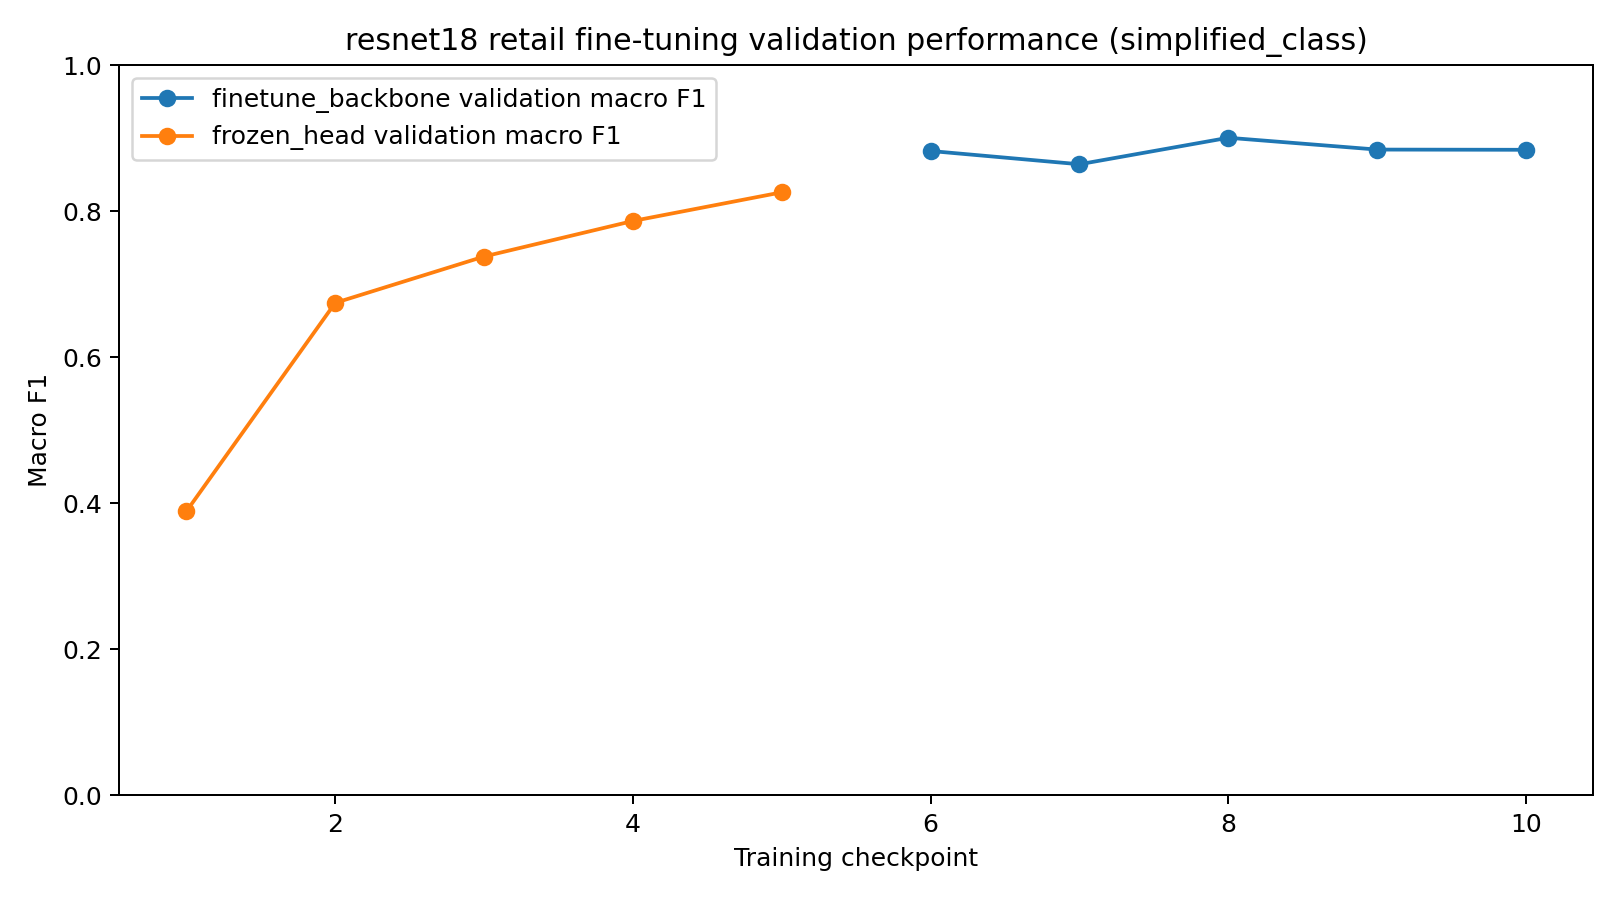

**confusion_matrix.png**

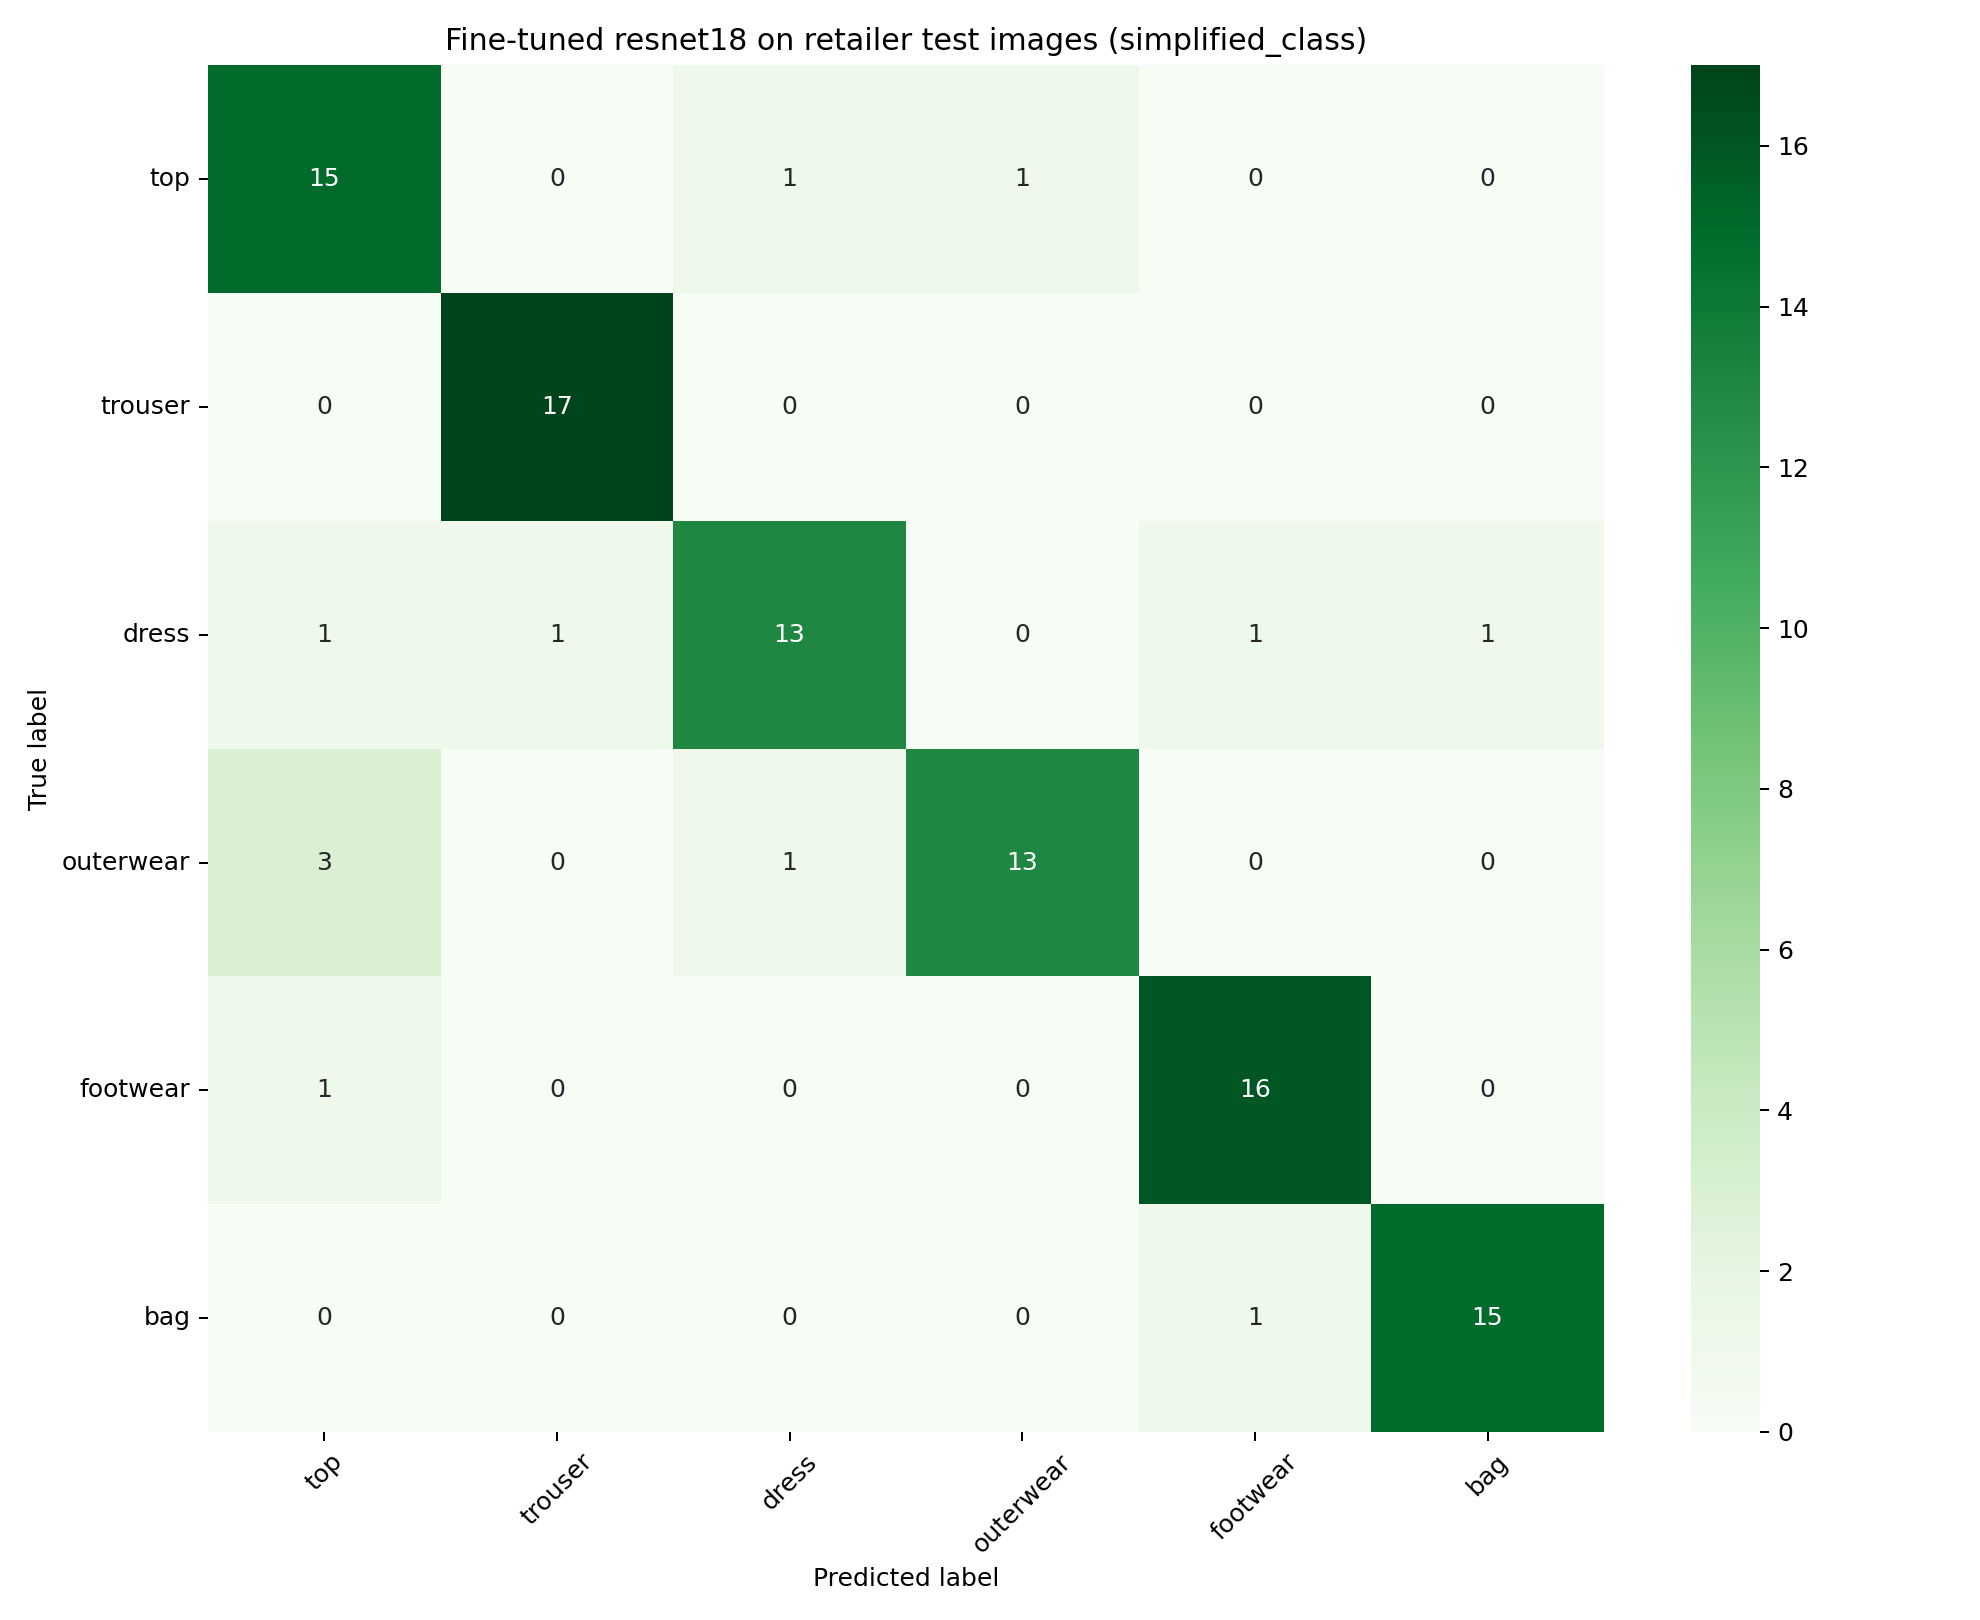

In [107]:
preferred_simplified_dir = None
for candidate in [
    simplified6_resnet18_full_dir,
    simplified6_mobilenet_full_dir,
    simplified6_resnet18_smoke_dir,
    simplified6_mobilenet_smoke_dir,
]:
    if (candidate / "metrics_summary.json").exists():
        preferred_simplified_dir = candidate
        break

if preferred_simplified_dir is None:
    display(Markdown("Run a simplified smoke or full experiment to generate plots."))
else:
    print(f"Displaying simplified real-image results from: {preferred_simplified_dir}")
    history_path = preferred_simplified_dir / "training_history.csv"
    report_path = preferred_simplified_dir / "classification_report.csv"
    if history_path.exists():
        display(pd.read_csv(history_path))
    if report_path.exists():
        display(pd.read_csv(report_path).head(12))
    for plot_name in ["training_curve.png", "confusion_matrix.png"]:
        plot_path = preferred_simplified_dir / plot_name
        if plot_path.exists():
            display(Markdown(f"**{plot_path.name}**"))
            display(IPyImage(filename=str(plot_path)))

### Manual Curation Loop

After the first full simplified-label run, use the confusion matrix and per-class F1 scores to identify the worst simplified groups. The likely candidates are `top`, `outerwear`, and `footwear`. For those groups, generate contact sheets from the raw images with `scripts/make_simplified6_contact_sheets.py`, remove images that are mislabeled or visually ambiguous, then regenerate the curated split and retrain the better backbone.

Rejected examples should be preserved for audit under `data/retail_images/rejected/simplified6/`, with a manifest such as `data/retail_images/metadata/simplified6_curation_rejects.csv`. The curated retraining split should be named `splits_raw_full_simplified6_curated.csv` so that the before/after comparison stays explicit.

## 8.4 Testing the Fine-Tuned Model on Real-World Images

The curated retail experiment above still uses product-style images collected through a controlled pipeline. As a final domain-shift check, I test the best simplified-label transfer-learning model on a small set of personal real-world images from outside that pipeline. These images include phone photos, screenshots, varied backgrounds, partial crops, and people wearing multiple garments.

This is not a statistically reliable benchmark: the sample is too small and several images contain more than one clothing item. I therefore treat it as a qualitative holdout spot check. For the quantitative summary, each image is labeled by the **dominant visible garment** when it fits one of the six simplified classes from the retail experiment: `top`, `trouser`, `dress`, `outerwear`, `footwear`, and `bag`. Images that are ambiguous or outside this taxonomy are marked `unidentified`; they are still shown in the qualitative table, but they are excluded from accuracy and macro F1.


In [108]:
import shutil
import subprocess
import tempfile
import zipfile
from pathlib import Path

from PIL import Image, ImageOps, ImageDraw

REAL_WORLD_ZIP = Path("/Users/ashley/Desktop/real world.zip")
REAL_WORLD_DATA_DIR = Path("data/real_world_images")
REAL_WORLD_RAW_DIR = REAL_WORLD_DATA_DIR / "raw"
REAL_WORLD_METADATA_DIR = REAL_WORLD_DATA_DIR / "metadata"
REAL_WORLD_RESULTS_DIR = Path("results/real_world_eval")
REAL_WORLD_MANIFEST_PATH = REAL_WORLD_METADATA_DIR / "manifest.csv"
REAL_WORLD_PREDICTIONS_PATH = REAL_WORLD_RESULTS_DIR / "predictions.csv"
REAL_WORLD_CONTACT_SHEET_PATH = REAL_WORLD_RESULTS_DIR / "real_world_predictions.png"
REAL_WORLD_MODEL_DIR = RETAIL_RESULTS_DIR / "simplified6_raw_full_resnet18_curated"
REAL_WORLD_MODEL_PATH = REAL_WORLD_MODEL_DIR / "resnet18_retail_finetuned.pt"
REAL_WORLD_METRICS_PATH = REAL_WORLD_MODEL_DIR / "metrics_summary.json"

REAL_WORLD_RAW_DIR.mkdir(parents=True, exist_ok=True)
REAL_WORLD_METADATA_DIR.mkdir(parents=True, exist_ok=True)
REAL_WORLD_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

REAL_WORLD_LABELS = {
    "000024400034.JPEG": ("top", "dominant visible white top"),
    "ACS_0641.JPG": ("outerwear", "dominant white jacket/outer layer"),
    "IMG_2644.jpg": ("top", "dominant colorful sleeveless top"),
    "IMG_2645.jpg": ("top", "dominant white top"),
    "IMG_2646.PNG": ("trouser", "pants close-up"),
    "IMG_2647.PNG": ("top", "dominant white sweater/top"),
    "IMG_2648.PNG": ("unidentified", "romper/one-piece outfit; ambiguous between top and dress"),
    "IMG_2649.PNG": ("trouser", "dominant pants/overalls lower garment"),
    "IMG_2650.jpg": ("footwear", "sneakers"),
    "IMG_4078.jpg": ("dress", "dominant blue dress"),
    "IMG_0746.heic": ("top", "hoodie/pullover; simplified as top"),
}
SUPPORTED_REAL_WORLD_EXTENSIONS = {".jpg", ".jpeg", ".png"}

if not REAL_WORLD_ZIP.exists():
    raise FileNotFoundError(f"Missing real-world image archive: {REAL_WORLD_ZIP}")

manifest_rows = []
with zipfile.ZipFile(REAL_WORLD_ZIP) as archive:
    for member in archive.infolist():
        member_path = Path(member.filename)
        filename = member_path.name
        if member.is_dir() or "__MACOSX" in member_path.parts or filename.startswith("._"):
            continue

        suffix = member_path.suffix.lower()
        if suffix not in SUPPORTED_REAL_WORLD_EXTENSIONS and suffix != ".heic":
            continue

        expected_label, notes = REAL_WORLD_LABELS.get(filename, ("unidentified", "unlabeled extra image; excluded from scored metrics"))
        status = "included"
        output_filename = filename
        output_path = REAL_WORLD_RAW_DIR / output_filename

        with archive.open(member) as source, output_path.open("wb") as target:
            shutil.copyfileobj(source, target)

        if suffix == ".heic":
            converted_path = REAL_WORLD_RAW_DIR / f"{Path(filename).stem}.jpg"
            conversion = subprocess.run(
                ["sips", "-s", "format", "jpeg", str(output_path), "--out", str(converted_path)],
                capture_output=True,
                text=True,
            )
            try:
                with Image.open(converted_path) as converted_image:
                    converted_image.verify()
                output_filename = converted_path.name
                output_path = converted_path
                status = "included"
                if expected_label == "unidentified":
                    notes = "HEIC converted; excluded from scored metrics unless manually relabeled"
            except Exception as error:
                status = "skipped"
                notes = f"HEIC conversion unavailable or invalid: {type(error).__name__}"
                if converted_path.exists():
                    converted_path.unlink()

                # On macOS, sips can fail on HEIC while Quick Look still produces a valid thumbnail.
                with tempfile.TemporaryDirectory() as thumbnail_dir:
                    thumbnail_result = subprocess.run(
                        ["qlmanage", "-t", "-s", "1024", "-o", thumbnail_dir, str(output_path)],
                        capture_output=True,
                        text=True,
                    )
                    thumbnail_path = Path(thumbnail_dir) / f"{filename}.png"
                    fallback_path = REAL_WORLD_RAW_DIR / f"{Path(filename).stem}.png"
                    if thumbnail_result.returncode == 0 and thumbnail_path.exists():
                        shutil.copyfile(thumbnail_path, fallback_path)
                        try:
                            with Image.open(fallback_path) as fallback_image:
                                fallback_image.verify()
                            output_filename = fallback_path.name
                            output_path = fallback_path
                            status = "included"
                        except Exception as fallback_error:
                            status = "skipped"
                            notes = f"HEIC Quick Look fallback invalid: {type(fallback_error).__name__}"
                            if fallback_path.exists():
                                fallback_path.unlink()
                    elif conversion.returncode != 0:
                        notes = f"HEIC conversion failed: {conversion.stderr.strip() or conversion.stdout.strip()}"
            if conversion.returncode != 0 and status != "included":
                notes = f"HEIC conversion failed: {conversion.stderr.strip() or conversion.stdout.strip()}"

        if status == "included":
            try:
                with Image.open(output_path) as image:
                    image.verify()
            except Exception as error:
                status = "skipped"
                notes = f"PIL could not validate image: {type(error).__name__}"

        manifest_rows.append({
            "filename": output_filename,
            "path": str(output_path),
            "expected_simplified_class": expected_label,
            "notes": notes,
            "status": status,
        })

real_world_manifest = pd.DataFrame(manifest_rows).sort_values("filename").reset_index(drop=True)
real_world_manifest.to_csv(REAL_WORLD_MANIFEST_PATH, index=False)

print(f"Manifest rows: {len(real_world_manifest)}")
print(f"Included rows: {(real_world_manifest['status'] == 'included').sum()}")
print(f"Manifest written to: {REAL_WORLD_MANIFEST_PATH}")
display(real_world_manifest)


Manifest rows: 11
Included rows: 11
Manifest written to: data/real_world_images/metadata/manifest.csv


,filename,path,expected_simplified_class,notes,status
0,000024400034.JPEG,data/real_world_images/raw/000024400034.JPEG,top,dominant visible white top,included
1,ACS_0641.JPG,data/real_world_images/raw/ACS_0641.JPG,outerwear,dominant white jacket/outer layer,included
2,IMG_0746.jpg,data/real_world_images/raw/IMG_0746.jpg,unidentified,HEIC converted; excluded from scored metrics u...,included
3,IMG_2644.jpg,data/real_world_images/raw/IMG_2644.jpg,top,dominant colorful sleeveless top,included
4,IMG_2645.jpg,data/real_world_images/raw/IMG_2645.jpg,top,dominant white top,included
5,IMG_2646.PNG,data/real_world_images/raw/IMG_2646.PNG,trouser,pants close-up,included
6,IMG_2647.PNG,data/real_world_images/raw/IMG_2647.PNG,top,dominant white sweater/top,included
7,IMG_2648.PNG,data/real_world_images/raw/IMG_2648.PNG,unidentified,romper/one-piece outfit; ambiguous between top...,included
8,IMG_2649.PNG,data/real_world_images/raw/IMG_2649.PNG,trouser,dominant pants/overalls lower garment,included
9,IMG_2650.jpg,data/real_world_images/raw/IMG_2650.jpg,footwear,sneakers,included


In [109]:
import sys

import torch
from sklearn.metrics import accuracy_score, f1_score
from torch import nn
from torchvision import models

sys.path.append(str(Path("scripts").resolve()))
from train_retail_finetune import build_transforms, device as retail_device

if not REAL_WORLD_MODEL_PATH.exists():
    raise FileNotFoundError(f"Missing curated real-image model: {REAL_WORLD_MODEL_PATH}")
if not REAL_WORLD_METRICS_PATH.exists():
    raise FileNotFoundError(f"Missing curated real-image metrics: {REAL_WORLD_METRICS_PATH}")

real_world_metrics = json.loads(REAL_WORLD_METRICS_PATH.read_text())
real_world_class_names = real_world_metrics["class_names"]
if real_world_class_names != SIMPLIFIED6_CLASSES:
    raise ValueError(
        f"Unexpected class order in {REAL_WORLD_METRICS_PATH}: {real_world_class_names}"
    )

run_device = retail_device()
_, real_world_eval_transform = build_transforms()
real_world_model = models.resnet18(weights=None)
real_world_model.fc = nn.Linear(real_world_model.fc.in_features, len(real_world_class_names))
real_world_model.load_state_dict(torch.load(REAL_WORLD_MODEL_PATH, map_location="cpu"))
real_world_model = real_world_model.to(run_device)
real_world_model.eval()

prediction_rows = []
included_manifest = real_world_manifest[real_world_manifest["status"] == "included"].copy()

with torch.no_grad():
    for row in included_manifest.itertuples(index=False):
        with Image.open(row.path) as image:
            image = ImageOps.exif_transpose(image).convert("RGB")
            input_tensor = real_world_eval_transform(image).unsqueeze(0).to(run_device)

        probabilities = torch.softmax(real_world_model(input_tensor), dim=1).cpu().numpy()[0]
        top_indices = probabilities.argsort()[::-1][:3]
        expected = row.expected_simplified_class if isinstance(row.expected_simplified_class, str) else ""
        predicted = real_world_class_names[top_indices[0]]
        is_scored_label = expected in real_world_class_names
        prediction_rows.append({
            "filename": row.filename,
            "path": row.path,
            "expected_simplified_class": expected,
            "predicted_class": predicted,
            "top1_confidence": float(probabilities[top_indices[0]]),
            "top2_class": real_world_class_names[top_indices[1]],
            "top2_confidence": float(probabilities[top_indices[1]]),
            "top3_class": real_world_class_names[top_indices[2]],
            "top3_confidence": float(probabilities[top_indices[2]]),
            "confidence_margin": float(probabilities[top_indices[0]] - probabilities[top_indices[1]]),
            "correct": bool(predicted == expected) if is_scored_label else np.nan,
            "notes": row.notes,
        })

real_world_predictions = pd.DataFrame(prediction_rows)
real_world_predictions.to_csv(REAL_WORLD_PREDICTIONS_PATH, index=False)

scored_predictions = real_world_predictions[
    real_world_predictions["expected_simplified_class"].isin(real_world_class_names)
].copy()
unidentified_predictions = real_world_predictions[
    ~real_world_predictions["expected_simplified_class"].isin(real_world_class_names)
].copy()
print(f"Predictions written to: {REAL_WORLD_PREDICTIONS_PATH}")
if not scored_predictions.empty:
    real_world_accuracy = accuracy_score(
        scored_predictions["expected_simplified_class"],
        scored_predictions["predicted_class"],
    )
    represented_classes = scored_predictions["expected_simplified_class"].nunique()
    print(f"Scored real-world accuracy: {real_world_accuracy:.3f} on {len(scored_predictions)} images")
    if represented_classes >= 2:
        real_world_macro_f1 = f1_score(
            scored_predictions["expected_simplified_class"],
            scored_predictions["predicted_class"],
            labels=real_world_class_names,
            average="macro",
            zero_division=0,
        )
        print(f"Scored real-world macro F1: {real_world_macro_f1:.3f}")
    else:
        print("Macro F1 suppressed because fewer than two scored classes are represented.")
else:
    print("No included rows have one of the six scored model classes.")
if not unidentified_predictions.empty:
    print(f"Unidentified/unscored rows: {len(unidentified_predictions)}")

display(real_world_predictions[[
    "filename",
    "expected_simplified_class",
    "predicted_class",
    "top1_confidence",
    "top2_class",
    "top2_confidence",
    "confidence_margin",
    "correct",
    "notes",
]])


Predictions written to: results/real_world_eval/predictions.csv
Scored real-world accuracy: 0.778 on 9 images
Scored real-world macro F1: 0.537
Unidentified/unscored rows: 2


,filename,expected_simplified_class,predicted_class,top1_confidence,top2_class,top2_confidence,confidence_margin,correct,notes
0,000024400034.JPEG,top,top,0.914034,dress,0.071459,0.842575,True,dominant visible white top
1,ACS_0641.JPG,outerwear,outerwear,0.325661,top,0.314841,0.010820,True,dominant white jacket/outer layer
2,IMG_0746.jpg,unidentified,outerwear,0.598797,top,0.349078,0.249719,NaN,HEIC converted; excluded from scored metrics u...
3,IMG_2644.jpg,top,top,0.816211,outerwear,0.092318,0.723892,True,dominant colorful sleeveless top
4,IMG_2645.jpg,top,top,0.953035,outerwear,0.023861,0.929173,True,dominant white top
5,IMG_2646.PNG,trouser,outerwear,0.396579,trouser,0.181756,0.214823,False,pants close-up
6,IMG_2647.PNG,top,top,0.794182,outerwear,0.137021,0.657160,True,dominant white sweater/top
7,IMG_2648.PNG,unidentified,top,0.875371,dress,0.091137,0.784233,NaN,romper/one-piece outfit; ambiguous between top...
8,IMG_2649.PNG,trouser,trouser,0.482782,dress,0.194392,0.288390,True,dominant pants/overalls lower garment
9,IMG_2650.jpg,footwear,footwear,0.684184,bag,0.135177,0.549007,True,sneakers


Prediction contact sheet written to: results/real_world_eval/real_world_predictions.png


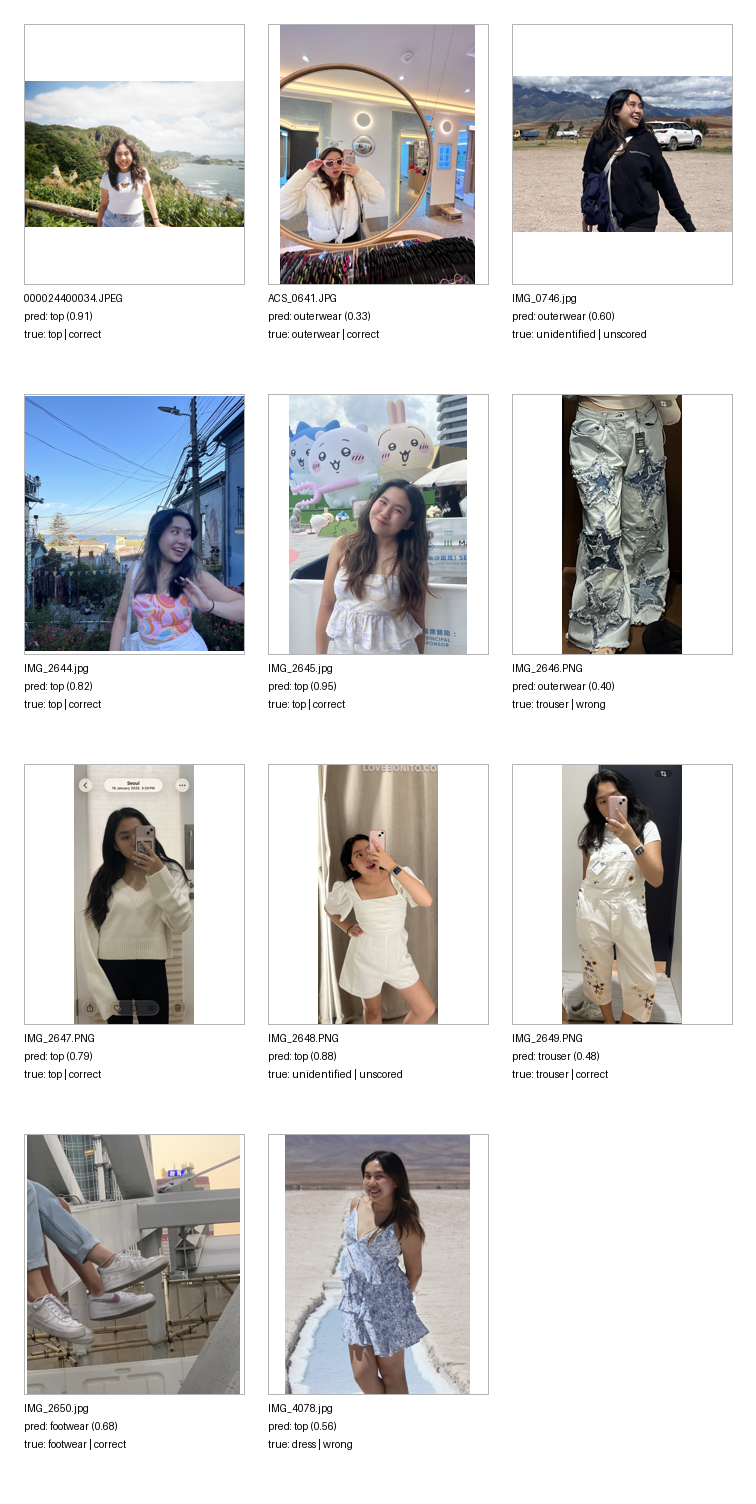

In [114]:
def make_real_world_prediction_sheet(predictions: pd.DataFrame, output_path: Path) -> None:
    if predictions.empty:
        raise ValueError("No real-world predictions are available to plot.")

    thumb_w, thumb_h = 220, 260
    label_h = 86
    pad = 24
    cols = 3
    rows = int(np.ceil(len(predictions) / cols))
    sheet_w = cols * (thumb_w + pad) + pad
    sheet_h = rows * (thumb_h + label_h + pad) + pad
    sheet = Image.new("RGB", (sheet_w, sheet_h), "white")
    draw = ImageDraw.Draw(sheet)

    for index, row in enumerate(predictions.itertuples(index=False)):
        grid_row, grid_col = divmod(index, cols)
        x = pad + grid_col * (thumb_w + pad)
        y = pad + grid_row * (thumb_h + label_h + pad)

        with Image.open(row.path) as image:
            image = ImageOps.exif_transpose(image).convert("RGB")
            image.thumbnail((thumb_w, thumb_h))
            image_x = x + (thumb_w - image.width) // 2
            image_y = y + (thumb_h - image.height) // 2
            sheet.paste(image, (image_x, image_y))

        draw.rectangle([x, y, x + thumb_w, y + thumb_h], outline=(180, 180, 180), width=1)
        label_y = y + thumb_h + 8
        expected = row.expected_simplified_class or "unlabeled"
        if pd.isna(row.correct):
            correctness = "unscored"
        else:
            correctness = "correct" if bool(row.correct) else "wrong"
        label_lines = [
            row.filename,
            f"pred: {row.predicted_class} ({row.top1_confidence:.2f})",
            f"true: {expected} | {correctness}",
        ]
        for offset, line in enumerate(label_lines):
            draw.text((x, label_y + 18 * offset), line[:34], fill=(0, 0, 0))

    output_path.parent.mkdir(parents=True, exist_ok=True)
    sheet.save(output_path)

if real_world_predictions.empty:
    display(Markdown("No included real-world images were available for the prediction contact sheet."))
else:
    make_real_world_prediction_sheet(real_world_predictions, REAL_WORLD_CONTACT_SHEET_PATH)
    print(f"Prediction contact sheet written to: {REAL_WORLD_CONTACT_SHEET_PATH}")
    display(IPyImage(filename=str(REAL_WORLD_CONTACT_SHEET_PATH)))

real_world_skipped = real_world_manifest[real_world_manifest["status"] != "included"]
if not real_world_skipped.empty:
    display(Markdown("**Skipped real-world files**"))
    display(real_world_skipped)


The real-world results should be interpreted as a stress test rather than a replacement for the held-out retail test set. These photos differ from catalog images in several ways that make the task harder: people and backgrounds are visible, crops are inconsistent, screenshots introduce interface artifacts, and some examples contain multiple garments. The six-class label space also compresses many visual distinctions, so ambiguous examples such as rompers are marked `unidentified` and excluded from scored metrics, while hoodie/pullover-like garments are scored as `top` under the simplified label mapping.

The most useful evidence from this section is therefore not only the small-sample accuracy, but also the pattern of confidence. High-confidence correct predictions suggest that the ImageNet-pretrained retail model learned transferable garment cues. High-confidence mistakes point to remaining domain-gap issues that would require a larger labeled real-world set, more augmentation, or labels designed for outfit-level images rather than isolated products.


## 8.5 Confidence, Human Review, and Selective Prediction

The real-world spot check above asks whether the transfer-learning model can classify images from outside the curated retail pipeline. A practical deployment question is slightly different: **when should the model be trusted, and when should a human review the image instead?**

This section uses the model's top predicted probability as a simple confidence score. I compare three acceptance thresholds: `0.50`, `0.70`, and `0.85`. Images above the threshold are accepted automatically; images below it are routed to human review. The `unidentified` examples remain visible because they are important deployment failures, but they are excluded from scored accuracy and macro F1 because they are outside the six-class model vocabulary.


In [115]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", str(Path(".matplotlib").resolve()))
os.environ.setdefault("MPLBACKEND", "Agg")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.metrics import accuracy_score, f1_score

REAL_WORLD_RESULTS_DIR = Path("results/real_world_eval")
REAL_WORLD_PREDICTIONS_PATH = REAL_WORLD_RESULTS_DIR / "predictions.csv"
SELECTIVE_PREDICTION_SUMMARY_PATH = REAL_WORLD_RESULTS_DIR / "selective_prediction_summary.csv"
SELECTIVE_PREDICTION_PLOT_PATH = REAL_WORLD_RESULTS_DIR / "selective_prediction_tradeoff.png"

SCORED_REAL_WORLD_CLASSES = ["top", "trouser", "dress", "outerwear", "footwear", "bag"]
SELECTIVE_CONFIDENCE_THRESHOLDS = [0.50, 0.70, 0.85]

if not REAL_WORLD_PREDICTIONS_PATH.exists():
    raise FileNotFoundError(
        f"Missing real-world predictions: {REAL_WORLD_PREDICTIONS_PATH}. Run section 8.4 first."
    )

real_world_predictions_for_review = pd.read_csv(REAL_WORLD_PREDICTIONS_PATH)
scored_real_world_predictions = real_world_predictions_for_review[
    real_world_predictions_for_review["expected_simplified_class"].isin(SCORED_REAL_WORLD_CLASSES)
].copy()
unscored_real_world_predictions = real_world_predictions_for_review[
    ~real_world_predictions_for_review["expected_simplified_class"].isin(SCORED_REAL_WORLD_CLASSES)
].copy()

if scored_real_world_predictions.empty:
    raise ValueError("No scored six-class real-world rows are available for selective prediction.")

scored_real_world_predictions["correct_bool"] = (
    scored_real_world_predictions["predicted_class"]
    == scored_real_world_predictions["expected_simplified_class"]
)

selective_rows = []
for threshold in SELECTIVE_CONFIDENCE_THRESHOLDS:
    accepted = scored_real_world_predictions[
        scored_real_world_predictions["top1_confidence"] >= threshold
    ].copy()
    reviewed = scored_real_world_predictions[
        scored_real_world_predictions["top1_confidence"] < threshold
    ].copy()
    high_confidence_unscored = unscored_real_world_predictions[
        unscored_real_world_predictions["top1_confidence"] >= threshold
    ].copy()

    if accepted.empty:
        accepted_accuracy = np.nan
        accepted_macro_f1 = np.nan
        accepted_correct = 0
    else:
        accepted_accuracy = accuracy_score(
            accepted["expected_simplified_class"],
            accepted["predicted_class"],
        )
        accepted_correct = int(accepted["correct_bool"].sum())
        accepted_macro_f1 = (
            f1_score(
                accepted["expected_simplified_class"],
                accepted["predicted_class"],
                average="macro",
                zero_division=0,
            )
            if accepted["expected_simplified_class"].nunique() >= 2
            else np.nan
        )

    selective_rows.append({
        "confidence_threshold": threshold,
        "scored_total_images": len(scored_real_world_predictions),
        "accepted_scored_images": len(accepted),
        "reviewed_scored_images": len(reviewed),
        "scored_coverage": len(accepted) / len(scored_real_world_predictions),
        "accepted_correct_images": accepted_correct,
        "accepted_accuracy": accepted_accuracy,
        "accepted_macro_f1": accepted_macro_f1,
        "unscored_unidentified_images": len(unscored_real_world_predictions),
        "unscored_high_confidence_predictions": len(high_confidence_unscored),
    })

selective_prediction_summary = pd.DataFrame(selective_rows)
selective_prediction_summary.to_csv(SELECTIVE_PREDICTION_SUMMARY_PATH, index=False)

print(f"Selective prediction summary written to: {SELECTIVE_PREDICTION_SUMMARY_PATH}")
display(
    selective_prediction_summary.style.format({
        "confidence_threshold": "{:.2f}",
        "scored_coverage": "{:.3f}",
        "accepted_accuracy": "{:.3f}",
        "accepted_macro_f1": "{:.3f}",
    })
)


Selective prediction summary written to: results/real_world_eval/selective_prediction_summary.csv


,confidence_threshold,scored_total_images,accepted_scored_images,reviewed_scored_images,scored_coverage,accepted_correct_images,accepted_accuracy,accepted_macro_f1,unscored_unidentified_images,unscored_high_confidence_predictions
0,0.50,9,6,3,0.667,5,0.833,0.630,2,2
1,0.70,9,4,5,0.444,4,1.000,nan,2,1
2,0.85,9,2,7,0.222,2,1.000,nan,2,1


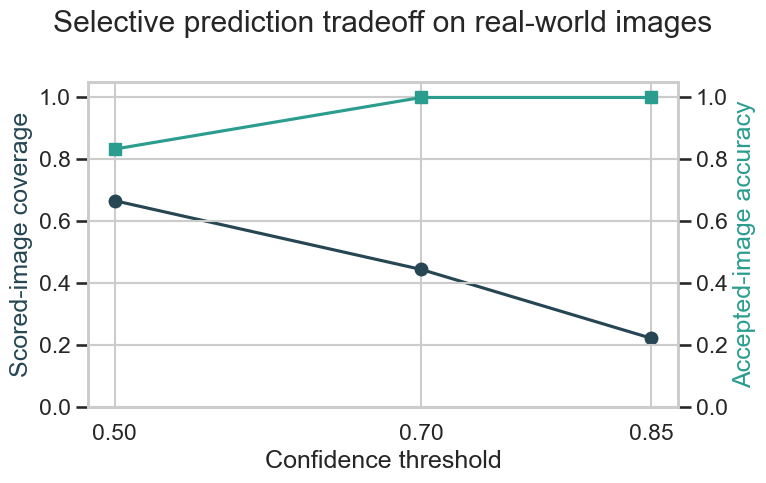

Selective prediction plot written to: results/real_world_eval/selective_prediction_tradeoff.png


**Rows that need human review or taxonomy revision**

,filename,expected_simplified_class,predicted_class,top1_confidence,confidence_margin,failure_category,review_note
2,IMG_0746.jpg,unidentified,outerwear,0.598797,0.249719,taxonomy_gap,Converted HEIC example is unlabeled/outside th...
5,IMG_2646.PNG,trouser,outerwear,0.396579,0.214823,crop_or_context_shift,Close crop of pants with unusual texture was p...
7,IMG_2648.PNG,unidentified,top,0.875371,0.784233,taxonomy_gap,Romper/one-piece outfit does not fit cleanly i...
10,IMG_4078.jpg,dress,top,0.561650,0.174886,class_boundary_confusion,"Dress silhouette was predicted as top, a plaus..."


In [112]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

ax1.plot(
    selective_prediction_summary["confidence_threshold"],
    selective_prediction_summary["scored_coverage"],
    marker="o",
    color="#264653",
    label="Coverage",
)
ax2.plot(
    selective_prediction_summary["confidence_threshold"],
    selective_prediction_summary["accepted_accuracy"],
    marker="s",
    color="#2A9D8F",
    label="Accepted accuracy",
)

ax1.set_xlabel("Confidence threshold")
ax1.set_ylabel("Scored-image coverage", color="#264653")
ax2.set_ylabel("Accepted-image accuracy", color="#2A9D8F")
ax1.set_ylim(0, 1.05)
ax2.set_ylim(0, 1.05)
ax1.set_xticks(SELECTIVE_CONFIDENCE_THRESHOLDS)
ax1.grid(axis="y", alpha=0.25)
fig.suptitle("Selective prediction tradeoff on real-world images")
fig.tight_layout()
fig.savefig(SELECTIVE_PREDICTION_PLOT_PATH, dpi=180)
plt.show()
print(f"Selective prediction plot written to: {SELECTIVE_PREDICTION_PLOT_PATH}")

failure_category_by_file = {
    "IMG_0746.jpg": "class_boundary_confusion",
    "IMG_0746.png": "class_boundary_confusion",
    "IMG_2648.PNG": "taxonomy_gap",
    "IMG_2646.PNG": "crop_or_context_shift",
    "IMG_4078.jpg": "class_boundary_confusion",
}
failure_reason_by_file = {
    "IMG_0746.jpg": "Hoodie/pullover is scored as top, but the model predicted outerwear.",
    "IMG_0746.png": "Hoodie/pullover is scored as top, but the model predicted outerwear.",
    "IMG_2648.PNG": "Romper/one-piece outfit does not fit cleanly into top versus dress taxonomy.",
    "IMG_2646.PNG": "Close crop of pants with unusual texture was predicted as outerwear.",
    "IMG_4078.jpg": "Dress silhouette was predicted as top, a plausible upper-body boundary confusion.",
}

review_mask = (
    ~real_world_predictions_for_review["expected_simplified_class"].isin(SCORED_REAL_WORLD_CLASSES)
    | (
        real_world_predictions_for_review["expected_simplified_class"].isin(SCORED_REAL_WORLD_CLASSES)
        & (
            real_world_predictions_for_review["predicted_class"]
            != real_world_predictions_for_review["expected_simplified_class"]
        )
    )
)
real_world_error_review = real_world_predictions_for_review[review_mask].copy()
real_world_error_review["failure_category"] = real_world_error_review["filename"].map(
    failure_category_by_file
).fillna("needs_review")
real_world_error_review["review_note"] = real_world_error_review["filename"].map(
    failure_reason_by_file
).fillna("Prediction should be reviewed manually before using it downstream.")

review_columns = [
    "filename",
    "expected_simplified_class",
    "predicted_class",
    "top1_confidence",
    "confidence_margin",
    "failure_category",
    "review_note",
]
display(Markdown("**Rows that need human review or taxonomy revision**"))
display(real_world_error_review[review_columns])


The selective-prediction table shows the practical tradeoff between automation and caution. Lower thresholds classify more images automatically, while higher thresholds send more images to review. This is useful because the model's real-world mistakes are not only ordinary class errors: some are taxonomy problems where the six trained classes are not expressive enough.

This extension connects directly to the course material. Sessions 9 and 40 focus on model quality and metrics; this section goes beyond one accuracy number by separating coverage from accepted-image accuracy. Session 11 raises the importance of data design and bias; the `unidentified` examples show how a label taxonomy can determine what counts as a valid prediction. Sessions 17 and 18 explain why convolutional features and transfer learning can work well on images, but the review table shows that representation learning still needs a human-facing decision rule when the deployment data are messy.


## 8.6 ML Flexibility I: Visual Retrieval with ResNet Embeddings

The fine-tuned ResNet does not have to be used only as a classifier. The layer before the final class head is also a learned visual representation. In this section, I reuse that representation for a different task: **image retrieval**. For each real-world image, the pipeline finds the nearest images in the curated retail dataset by cosine similarity in ResNet embedding space.

This is a practical modern ML pattern. Search, recommendation, duplicate detection, and human-review tools often use embeddings first, then let a person or a downstream model interpret the nearest neighbors. Here, retrieval asks whether the model's learned representation groups visually similar garments together even when the real-world image is messy or outside the exact six-class taxonomy.


In [120]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", str(Path(".matplotlib").resolve()))
os.environ.setdefault("MPLBACKEND", "Agg")

import numpy as np
import pandas as pd
import torch
from IPython.display import Image as IPyImage, Markdown, display
from PIL import Image, ImageDraw, ImageOps
from torch import nn
from torchvision import models, transforms

ML_FLEX_RESULTS_DIR = Path("results/ml_flexibility")
ML_FLEX_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

RETRIEVAL_NEIGHBORS_PATH = ML_FLEX_RESULTS_DIR / "retrieval_neighbors.csv"
RETRIEVAL_SUMMARY_PATH = ML_FLEX_RESULTS_DIR / "retrieval_summary.csv"
RETRIEVAL_CONTACT_SHEET_PATH = ML_FLEX_RESULTS_DIR / "retrieval_contact_sheet.png"
RETRIEVAL_K = 5

RETRIEVAL_RETAIL_SPLIT_PATH = Path("data/retail_images/metadata/splits_raw_full_simplified6.csv")
RETRIEVAL_REAL_WORLD_PREDICTIONS_PATH = Path("results/real_world_eval/predictions.csv")
RETRIEVAL_MODEL_PATH = Path("results/retail_finetune/simplified6_raw_full_resnet18_curated/resnet18_retail_finetuned.pt")
RETRIEVAL_CLASSES = ["top", "trouser", "dress", "outerwear", "footwear", "bag"]

for required_path in [RETRIEVAL_RETAIL_SPLIT_PATH, RETRIEVAL_REAL_WORLD_PREDICTIONS_PATH, RETRIEVAL_MODEL_PATH]:
    if not required_path.exists():
        raise FileNotFoundError(f"Missing required retrieval input: {required_path}")

retail_reference_df = pd.read_csv(RETRIEVAL_RETAIL_SPLIT_PATH).reset_index(drop=True)
real_world_retrieval_df = pd.read_csv(RETRIEVAL_REAL_WORLD_PREDICTIONS_PATH).reset_index(drop=True)
retail_reference_df = retail_reference_df[retail_reference_df["path"].map(lambda value: Path(value).exists())].reset_index(drop=True)
real_world_retrieval_df = real_world_retrieval_df[real_world_retrieval_df["path"].map(lambda value: Path(value).exists())].reset_index(drop=True)

if retail_reference_df.empty or real_world_retrieval_df.empty:
    raise ValueError("Retrieval needs at least one retail reference image and one real-world query image.")

retrieval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def choose_torch_device() -> torch.device:
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

retrieval_device = choose_torch_device()
retrieval_model = models.resnet18(weights=None)
retrieval_model.fc = nn.Linear(retrieval_model.fc.in_features, len(RETRIEVAL_CLASSES))
retrieval_model.load_state_dict(torch.load(RETRIEVAL_MODEL_PATH, map_location="cpu"))
retrieval_model.fc = nn.Identity()
retrieval_model = retrieval_model.to(retrieval_device)
retrieval_model.eval()


def embed_image_paths(paths: list[str], batch_size: int = 32) -> np.ndarray:
    embeddings = []
    with torch.no_grad():
        for start in range(0, len(paths), batch_size):
            batch_paths = paths[start:start + batch_size]
            images = []
            for image_path in batch_paths:
                with Image.open(image_path) as image:
                    image = ImageOps.exif_transpose(image).convert("RGB")
                    images.append(retrieval_transform(image))
            inputs = torch.stack(images).to(retrieval_device)
            features = retrieval_model(inputs).cpu().numpy()
            embeddings.append(features)
    embeddings = np.vstack(embeddings)
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    return embeddings / np.clip(norms, 1e-12, None)

print(f"Embedding {len(retail_reference_df)} retail reference images and {len(real_world_retrieval_df)} real-world query images on {retrieval_device}...")
retail_embeddings = embed_image_paths(retail_reference_df["path"].tolist())
real_world_embeddings = embed_image_paths(real_world_retrieval_df["path"].tolist())

similarity = real_world_embeddings @ retail_embeddings.T
top_neighbor_indices = np.argsort(-similarity, axis=1)[:, :RETRIEVAL_K]

neighbor_rows = []
for query_position, neighbor_positions in enumerate(top_neighbor_indices):
    query_row = real_world_retrieval_df.iloc[query_position]
    for rank, neighbor_position in enumerate(neighbor_positions, start=1):
        neighbor_row = retail_reference_df.iloc[int(neighbor_position)]
        neighbor_rows.append({
            "query_filename": query_row["filename"],
            "query_path": query_row["path"],
            "query_expected_class": query_row["expected_simplified_class"],
            "query_resnet_prediction": query_row["predicted_class"],
            "query_resnet_confidence": query_row["top1_confidence"],
            "neighbor_rank": rank,
            "neighbor_path": neighbor_row["path"],
            "neighbor_filename": Path(neighbor_row["path"]).name,
            "neighbor_simplified_class": neighbor_row["simplified_class"],
            "neighbor_fashion_mnist_class": neighbor_row.get("fashion_mnist_class", ""),
            "neighbor_split": neighbor_row["split"],
            "cosine_similarity": float(similarity[query_position, neighbor_position]),
        })

retrieval_neighbors_df = pd.DataFrame(neighbor_rows)
retrieval_neighbors_df.to_csv(RETRIEVAL_NEIGHBORS_PATH, index=False)

def summarize_neighbor_classes(group: pd.DataFrame) -> pd.Series:
    expected = group["query_expected_class"].iloc[0]
    top1_class = group[group["neighbor_rank"] == 1]["neighbor_simplified_class"].iloc[0]
    top5_classes = group.sort_values("neighbor_rank")["neighbor_simplified_class"].tolist()
    scored_expected = expected in RETRIEVAL_CLASSES
    return pd.Series({
        "query_expected_class": expected,
        "query_resnet_prediction": group["query_resnet_prediction"].iloc[0],
        "query_resnet_confidence": group["query_resnet_confidence"].iloc[0],
        "top1_neighbor_class": top1_class,
        "top1_similarity": group[group["neighbor_rank"] == 1]["cosine_similarity"].iloc[0],
        "top5_neighbor_classes": ", ".join(top5_classes),
        "top1_matches_expected": bool(top1_class == expected) if scored_expected else np.nan,
        "top5_contains_expected": bool(expected in top5_classes) if scored_expected else np.nan,
    })

retrieval_summary_rows = []
for query_filename, query_neighbors in retrieval_neighbors_df.groupby("query_filename", sort=False):
    summary_row = summarize_neighbor_classes(query_neighbors)
    summary_row["query_filename"] = query_filename
    retrieval_summary_rows.append(summary_row)
retrieval_summary_df = pd.DataFrame(retrieval_summary_rows)[
    [
        "query_filename",
        "query_expected_class",
        "query_resnet_prediction",
        "query_resnet_confidence",
        "top1_neighbor_class",
        "top1_similarity",
        "top5_neighbor_classes",
        "top1_matches_expected",
        "top5_contains_expected",
    ]
]
retrieval_summary_df.to_csv(RETRIEVAL_SUMMARY_PATH, index=False)

print(f"Retrieval neighbors written to: {RETRIEVAL_NEIGHBORS_PATH}")
print(f"Retrieval summary written to: {RETRIEVAL_SUMMARY_PATH}")
display(retrieval_summary_df)


Embedding 720 retail reference images and 10 real-world query images on mps...
Retrieval neighbors written to: results/ml_flexibility/retrieval_neighbors.csv
Retrieval summary written to: results/ml_flexibility/retrieval_summary.csv


,query_filename,query_expected_class,query_resnet_prediction,query_resnet_confidence,top1_neighbor_class,top1_similarity,top5_neighbor_classes,top1_matches_expected,top5_contains_expected
0,000024400034.JPEG,top,top,0.914034,top,0.743955,"top, top, top, top, dress",True,True
1,ACS_0641.JPG,outerwear,outerwear,0.325662,top,0.730629,"top, top, bag, top, top",False,False
2,IMG_2644.jpg,top,top,0.816210,dress,0.762620,"dress, top, top, outerwear, top",False,True
3,IMG_2645.jpg,top,top,0.953035,top,0.763708,"top, top, top, top, top",True,True
4,IMG_2646.PNG,trouser,outerwear,0.396578,outerwear,0.704605,"outerwear, dress, trouser, dress, dress",False,True
5,IMG_2647.PNG,top,top,0.794181,top,0.781439,"top, top, top, top, top",True,True
6,IMG_2648.PNG,unidentified,top,0.875371,top,0.796127,"top, top, top, top, top",NaN,NaN
7,IMG_2649.PNG,trouser,trouser,0.482782,dress,0.733517,"dress, trouser, dress, trouser, dress",False,True
8,IMG_2650.jpg,footwear,footwear,0.684183,footwear,0.787021,"footwear, footwear, footwear, footwear, footwear",True,True
9,IMG_4078.jpg,dress,top,0.561650,top,0.768017,"top, top, dress, top, top",False,True


Retrieval contact sheet written to: results/ml_flexibility/retrieval_contact_sheet.png


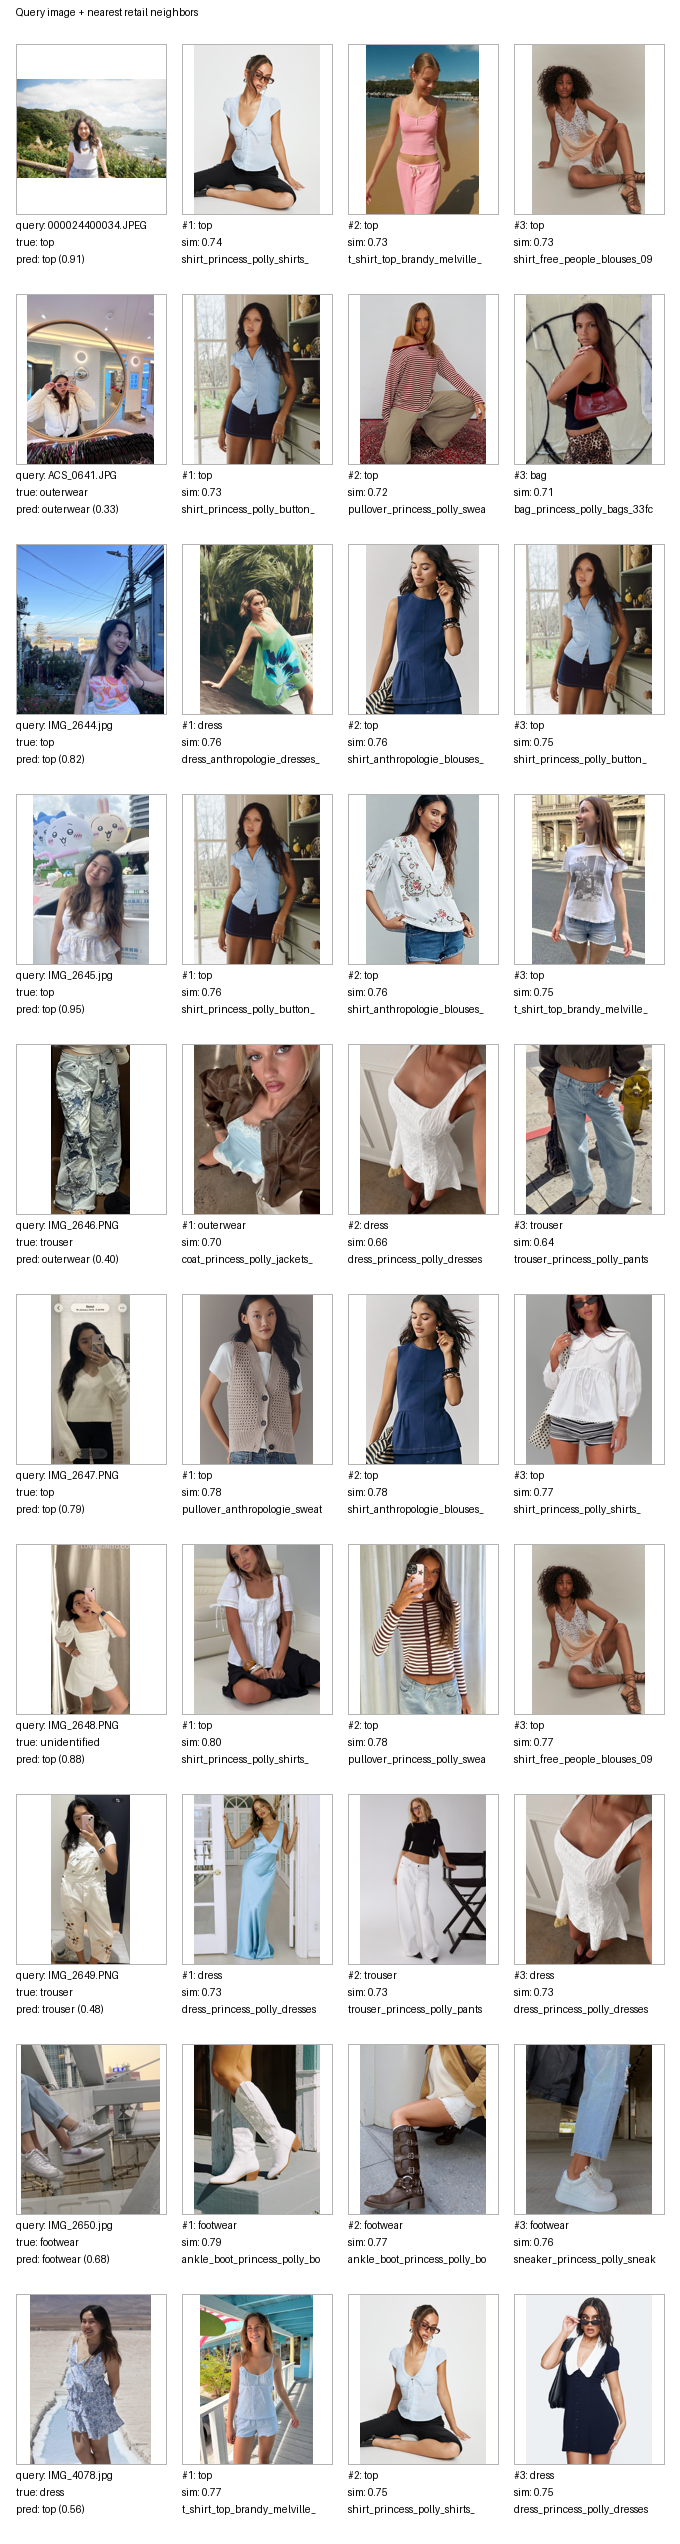

Top-1 retrieval label match rate on scored real-world images: 0.444
Top-5 retrieval contains expected label rate: 0.889


In [121]:
def make_retrieval_contact_sheet(
    queries: pd.DataFrame,
    neighbors: pd.DataFrame,
    output_path: Path,
    max_queries: int = 11,
    neighbors_to_show: int = 3,
) -> None:
    query_rows = queries.head(max_queries).copy()
    thumb_w, thumb_h = 150, 170
    label_h = 64
    pad = 16
    cols = 1 + neighbors_to_show
    rows = len(query_rows)
    sheet_w = cols * (thumb_w + pad) + pad
    sheet_h = rows * (thumb_h + label_h + pad) + pad + 28
    sheet = Image.new("RGB", (sheet_w, sheet_h), "white")
    draw = ImageDraw.Draw(sheet)
    draw.text((pad, 6), "Query image + nearest retail neighbors", fill=(0, 0, 0))

    def paste_thumb(image_path: str, x: int, y: int) -> None:
        with Image.open(image_path) as image:
            image = ImageOps.exif_transpose(image).convert("RGB")
            image.thumbnail((thumb_w, thumb_h))
            image_x = x + (thumb_w - image.width) // 2
            image_y = y + (thumb_h - image.height) // 2
            sheet.paste(image, (image_x, image_y))
        draw.rectangle([x, y, x + thumb_w, y + thumb_h], outline=(180, 180, 180), width=1)

    for row_idx, query in enumerate(query_rows.itertuples(index=False)):
        y = pad + 28 + row_idx * (thumb_h + label_h + pad)
        x = pad
        paste_thumb(query.path, x, y)
        query_label = f"query: {query.filename}"
        expected_label = f"true: {query.expected_simplified_class}"
        pred_label = f"pred: {query.predicted_class} ({query.top1_confidence:.2f})"
        for offset, line in enumerate([query_label, expected_label, pred_label]):
            draw.text((x, y + thumb_h + 5 + 17 * offset), line[:28], fill=(0, 0, 0))

        query_neighbors = neighbors[
            (neighbors["query_filename"] == query.filename)
            & (neighbors["neighbor_rank"] <= neighbors_to_show)
        ].sort_values("neighbor_rank")
        for neighbor_idx, neighbor in enumerate(query_neighbors.itertuples(index=False), start=1):
            x = pad + neighbor_idx * (thumb_w + pad)
            paste_thumb(neighbor.neighbor_path, x, y)
            lines = [
                f"#{neighbor.neighbor_rank}: {neighbor.neighbor_simplified_class}",
                f"sim: {neighbor.cosine_similarity:.2f}",
                neighbor.neighbor_filename[:28],
            ]
            for offset, line in enumerate(lines):
                draw.text((x, y + thumb_h + 5 + 17 * offset), line[:28], fill=(0, 0, 0))

    output_path.parent.mkdir(parents=True, exist_ok=True)
    sheet.save(output_path)

make_retrieval_contact_sheet(real_world_retrieval_df, retrieval_neighbors_df, RETRIEVAL_CONTACT_SHEET_PATH)
print(f"Retrieval contact sheet written to: {RETRIEVAL_CONTACT_SHEET_PATH}")
display(IPyImage(filename=str(RETRIEVAL_CONTACT_SHEET_PATH)))

scored_retrieval_summary = retrieval_summary_df[
    retrieval_summary_df["query_expected_class"].isin(RETRIEVAL_CLASSES)
].copy()
if not scored_retrieval_summary.empty:
    top1_retrieval_match_rate = scored_retrieval_summary["top1_matches_expected"].mean()
    top5_retrieval_match_rate = scored_retrieval_summary["top5_contains_expected"].mean()
    print(f"Top-1 retrieval label match rate on scored real-world images: {top1_retrieval_match_rate:.3f}")
    print(f"Top-5 retrieval contains expected label rate: {top5_retrieval_match_rate:.3f}")


The retrieval output changes the interpretation of the ResNet from a closed classifier into a reusable representation model. Instead of only returning one label, the system can show visually similar retail examples next to a real-world query. That is useful for human review: a reviewer can see whether the model is comparing the image to plausible neighbors, and errors become easier to diagnose.

This is an ML-flexibility extension because the same learned features are reused for a new task without retraining. It connects to the syllabus topics on convolutions and transfer learning, while also moving toward a state-of-the-art pipeline pattern: embedding once, then using nearest-neighbor search for retrieval, recommendation, and review workflows.


## 8.7 ML Flexibility II: Optional Zero-Shot Classification with Image-Text Models

The retrieval section reused the fine-tuned ResNet representation. A second modern pipeline tests a different kind of flexibility: **zero-shot image-text classification**. Models such as CLIP can compare an image to text prompts, so they can classify into new label names without task-specific fine-tuning.

This cell is optional and intentionally low-risk. It uses `local_files_only=True`, so it will run only if the CLIP model is already cached locally. If the model is not available, the notebook records that the zero-shot extension was skipped rather than downloading anything or failing the run.


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from PIL import Image, ImageOps
from sklearn.metrics import accuracy_score, f1_score

ML_FLEX_RESULTS_DIR = Path("results/ml_flexibility")
ML_FLEX_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
ZERO_SHOT_PREDICTIONS_PATH = ML_FLEX_RESULTS_DIR / "zero_shot_predictions.csv"
ZERO_SHOT_COMPARISON_PATH = ML_FLEX_RESULTS_DIR / "zero_shot_comparison.csv"
ZERO_SHOT_MODEL_NAME = "openai/clip-vit-base-patch32"
ZERO_SHOT_CLASSES = ["top", "trouser", "dress", "outerwear", "footwear", "bag"]
ZERO_SHOT_REQUIRED_CACHE_FILES = [
    "config.json",
    "preprocessor_config.json",
    "tokenizer_config.json",
    "vocab.json",
    "merges.txt",
]
ZERO_SHOT_PROMPTS = {
    "top": "a photo of a top",
    "trouser": "a photo of trousers",
    "dress": "a photo of a dress",
    "outerwear": "a photo of outerwear",
    "footwear": "a photo of footwear",
    "bag": "a photo of a bag",
}

zero_shot_status = "not_run"
try:
    from huggingface_hub import try_to_load_from_cache
except Exception as error:
    zero_shot_status = "skipped"
    display(Markdown(
        "Zero-shot CLIP extension skipped because the local Hugging Face cache "
        f"could not be inspected (`{type(error).__name__}`). No model was downloaded."
    ))
else:
    def zero_shot_file_is_cached(filename):
        cached_path = try_to_load_from_cache(ZERO_SHOT_MODEL_NAME, filename)
        return isinstance(cached_path, str) and Path(cached_path).exists()

    missing_zero_shot_cache_files = [
        filename
        for filename in ZERO_SHOT_REQUIRED_CACHE_FILES
        if not zero_shot_file_is_cached(filename)
    ]
    if missing_zero_shot_cache_files:
        zero_shot_status = "skipped"
        display(Markdown(
            f"Zero-shot CLIP extension skipped because `{ZERO_SHOT_MODEL_NAME}` is not cached locally. "
            "This is expected in a fresh environment, and no model was downloaded. "
            f"Missing cached files include: `{', '.join(missing_zero_shot_cache_files[:3])}`."
        ))
    else:
        try:
            from transformers import CLIPModel, CLIPProcessor
            zero_shot_processor = CLIPProcessor.from_pretrained(
                ZERO_SHOT_MODEL_NAME,
                local_files_only=True,
            )
            zero_shot_model = CLIPModel.from_pretrained(
                ZERO_SHOT_MODEL_NAME,
                local_files_only=True,
            )
            zero_shot_status = "loaded"
        except Exception as error:
            zero_shot_status = "skipped"
            display(Markdown(
                f"Zero-shot CLIP extension skipped because the cached `{ZERO_SHOT_MODEL_NAME}` "
                f"files could not be loaded (`{type(error).__name__}`). No model was downloaded."
            ))

if zero_shot_status == "loaded":
    zero_shot_device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
    zero_shot_model = zero_shot_model.to(zero_shot_device)
    zero_shot_model.eval()
    zero_shot_predictions_input = pd.read_csv("results/real_world_eval/predictions.csv")
    prompts = [ZERO_SHOT_PROMPTS[class_name] for class_name in ZERO_SHOT_CLASSES]
    zero_shot_rows = []

    with torch.no_grad():
        for row in zero_shot_predictions_input.itertuples(index=False):
            with Image.open(row.path) as image:
                image = ImageOps.exif_transpose(image).convert("RGB")
            inputs = zero_shot_processor(
                text=prompts,
                images=image,
                return_tensors="pt",
                padding=True,
            ).to(zero_shot_device)
            outputs = zero_shot_model(**inputs)
            probabilities = outputs.logits_per_image.softmax(dim=1).cpu().numpy()[0]
            top_indices = probabilities.argsort()[::-1][:3]
            zero_shot_rows.append({
                "filename": row.filename,
                "path": row.path,
                "expected_simplified_class": row.expected_simplified_class,
                "resnet_prediction": row.predicted_class,
                "resnet_confidence": row.top1_confidence,
                "zero_shot_prediction": ZERO_SHOT_CLASSES[top_indices[0]],
                "zero_shot_confidence": float(probabilities[top_indices[0]]),
                "zero_shot_top2_class": ZERO_SHOT_CLASSES[top_indices[1]],
                "zero_shot_top2_confidence": float(probabilities[top_indices[1]]),
                "zero_shot_top3_class": ZERO_SHOT_CLASSES[top_indices[2]],
                "zero_shot_top3_confidence": float(probabilities[top_indices[2]]),
            })

    zero_shot_predictions_df = pd.DataFrame(zero_shot_rows)
    zero_shot_predictions_df.to_csv(ZERO_SHOT_PREDICTIONS_PATH, index=False)
    zero_shot_comparison_df = zero_shot_predictions_df[
        zero_shot_predictions_df["expected_simplified_class"].isin(ZERO_SHOT_CLASSES)
    ].copy()
    if not zero_shot_comparison_df.empty:
        zero_shot_comparison_df["resnet_correct"] = (
            zero_shot_comparison_df["resnet_prediction"]
            == zero_shot_comparison_df["expected_simplified_class"]
        )
        zero_shot_comparison_df["zero_shot_correct"] = (
            zero_shot_comparison_df["zero_shot_prediction"]
            == zero_shot_comparison_df["expected_simplified_class"]
        )
        zero_shot_comparison_df.to_csv(ZERO_SHOT_COMPARISON_PATH, index=False)
        print(f"Zero-shot predictions written to: {ZERO_SHOT_PREDICTIONS_PATH}")
        print(f"Zero-shot comparison written to: {ZERO_SHOT_COMPARISON_PATH}")
        print(f"ResNet accuracy on scored rows: {accuracy_score(zero_shot_comparison_df['expected_simplified_class'], zero_shot_comparison_df['resnet_prediction']):.3f}")
        print(f"Zero-shot accuracy on scored rows: {accuracy_score(zero_shot_comparison_df['expected_simplified_class'], zero_shot_comparison_df['zero_shot_prediction']):.3f}")
        if zero_shot_comparison_df["expected_simplified_class"].nunique() >= 2:
            print(f"Zero-shot macro F1 on scored rows: {f1_score(zero_shot_comparison_df['expected_simplified_class'], zero_shot_comparison_df['zero_shot_prediction'], average='macro', zero_division=0):.3f}")
    display(zero_shot_predictions_df)


If the optional zero-shot cell runs, it compares two different transfer-learning strategies. The ResNet result is task-specific transfer: start with ImageNet features and fine-tune on the curated retail dataset. CLIP-style zero-shot classification is language-guided transfer: use text prompts to define the target labels without training on this dataset.

If the cell skips, that is still an intentional result for this notebook environment. The required project remains reproducible without a network download, while the section documents how the same problem could be extended with a state-of-the-art image-text pipeline when the model is available.


## 9. Executive Summary
This notebook compares several approaches to multiclass image classification on **Fashion-MNIST** in order to answer a focused question: how much does a simple convolutional neural network improve performance relative to classical machine-learning baselines? To make that comparison fair, the same underlying dataset was prepared in two representations: **flattened 784-dimensional vectors** for the classical models and **28 × 28 image tensors** for the image-based models. The full pipeline included a majority-class baseline, Gaussian Naive Bayes, logistic regression, PCA + logistic regression, two small CNN configurations, and a later extension using a convolutional autoencoder to learn latent features for downstream classification.

On the clean benchmark, the best overall model was **CNN-small**, which achieved a **test macro F1 of 0.890**, while the strongest classical baseline, **PCA + Logistic Regression**, achieved **0.824**. This result supports the central claim of the notebook: once the task is genuinely visual, models that preserve spatial structure outperform models that treat the image as a flat vector of pixels. The confusion matrices reinforce this interpretation, since the remaining mistakes are concentrated in visually similar upper-body garments such as **T-shirt/top, shirt, pullover, and coat**, rather than being spread randomly across all classes.

To address the notebook’s main limitation, I then extended the analysis beyond the clean benchmark by testing the models on perturbed versions of the test set designed to better resemble real archive conditions. These shifts included small translations, rotations, blur, noise, brightness and contrast changes, and crop-and-pad distortions. Under this distribution shift, both models lost performance, but the **CNN remained much more robust**: its average macro F1 drop was **0.104**, compared with **0.431** for **PCA + Logistic Regression**. This makes the main takeaway stronger: the CNN is not only better on the benchmark itself, but also more stable once the images stop looking perfectly standardized.

A second flexibility-oriented extension used a small **convolutional autoencoder** to learn compact image representations without labels. Logistic regression trained on these latent features achieved a **test macro F1 of 0.820**, placing it close to the PCA baseline on the clean benchmark while showing a much smaller average performance drop under perturbation (**0.119**). This suggests that learned nonlinear representations transfer better than hand-engineered linear compression, even when they are not trained directly for classification. At the same time, the full CNN still performed best, which shows the advantage of task-specific supervised feature learning.

The biggest limitation of the original Fashion-MNIST benchmark is that it is still highly standardized rather than messy real-world image data. The images are centered, uniformly sized, grayscale, cleanly labeled, and class-balanced, and the train and test sets come from the same distribution. To address that limitation, I added two progressively harder checks: first a curated real-retail transfer-learning experiment, and then a small real-world holdout spot check using personal phone photos, screenshots, and archive-like images. I also added a practical selective-prediction extension that asks when the model should abstain and send an image to human review. The real-world sample is intentionally too small to serve as a reliable benchmark, but it tests whether the trained pipeline can ingest out-of-pipeline images and exposes the remaining domain gap caused by backgrounds, crops, multiple garments, lighting, and label ambiguity.

Overall, the notebook now supports a more nuanced conclusion than a simple benchmark comparison. On clean image data, CNNs outperform classical flattened-pixel baselines. Under moderate distribution shift, that advantage becomes even more meaningful, because the CNN remains substantially more robust. The autoencoder extension further shows that **representation learning itself matters**: even unsupervised learned features can transfer better than linear compression, though they still do not match a fully supervised CNN. The retail fine-tuning, real-world spot check, selective-prediction analysis, visual retrieval section, and optional zero-shot section extend that lesson beyond Fashion-MNIST: transfer learning can adapt the representation to more realistic images, learned embeddings can support search and review workflows, and image-text models can provide a no-fine-tuning comparison when available. A larger labeled real-world sample and a clear abstention policy would still be needed for a dependable archive-level system.

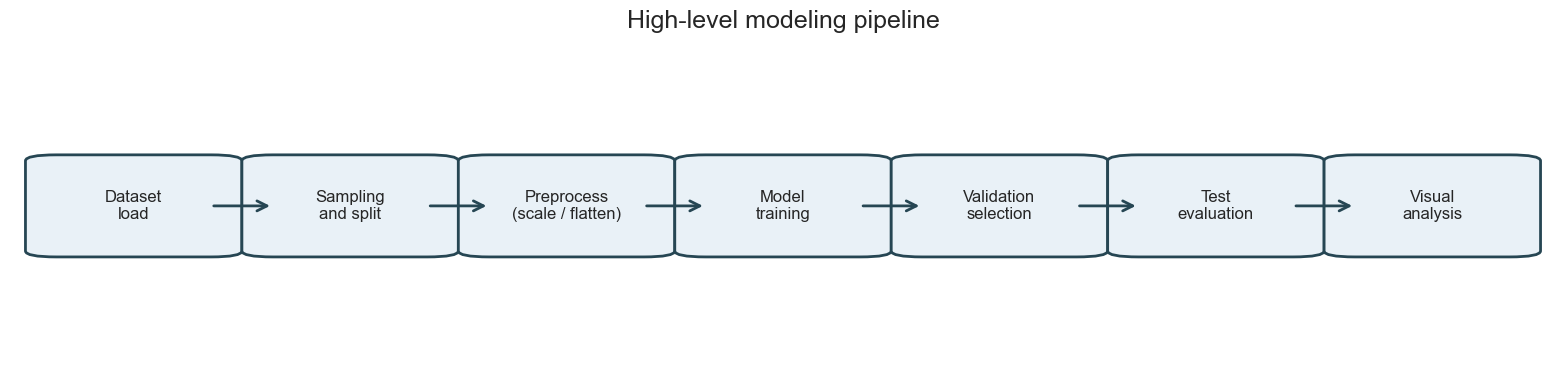

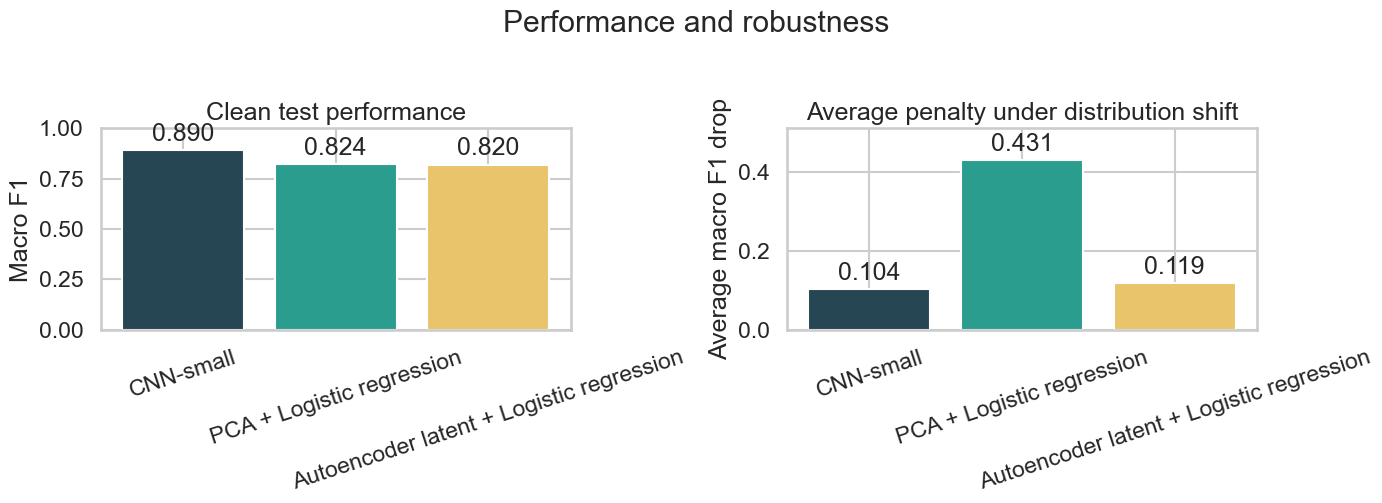

,model,clean_test_macro_f1,avg_shift_drop
0,CNN-small,0.890,0.104
1,PCA + Logistic regression,0.824,0.431
2,Autoencoder latent + Logistic regression,0.820,0.119


In [113]:
# Draw a compact pipeline diagram for the executive summary.
fig, ax = plt.subplots(figsize=(16, 4))
ax.axis("off")

steps = [
    "Dataset\nload",
    "Sampling\nand split",
    "Preprocess\n(scale / flatten)",
    "Model\ntraining",
    "Validation\nselection",
    "Test\nevaluation",
    "Visual\nanalysis",
]
x_positions = np.linspace(0.03, 0.87, len(steps))

for i, (x, label) in enumerate(zip(x_positions, steps)):
    box = FancyBboxPatch(
        (x, 0.35),
        0.1,
        0.3,
        boxstyle="round,pad=0.02",
        linewidth=2,
        edgecolor="#264653",
        facecolor="#E9F1F7",
    )
    ax.add_patch(box)
    ax.text(x + 0.05, 0.5, label, ha="center", va="center", fontsize=12)
    if i < len(steps) - 1:
        ax.annotate(
            "",
            xy=(x_positions[i + 1], 0.5),
            xytext=(x + 0.1, 0.5),
            arrowprops=dict(arrowstyle="->", lw=2, color="#264653"),
        )

plt.title("High-level modeling pipeline", pad=20)
plt.tight_layout()
plt.show()

summary_models = [
    "CNN-small" if "CNN-small" in set(combined_shift_df["model"]) else best_cnn_name,
    "PCA + Logistic regression",
    "Autoencoder latent + Logistic regression",
]
clean_scores = (
    combined_shift_df[combined_shift_df["shift"] == "Clean"]
    .set_index("model")["macro_f1"]
)
average_shift_drop = (
    combined_shift_df[combined_shift_df["shift"] != "Clean"]
    .groupby("model")["macro_f1_drop"]
    .mean()
)
compact_summary_df = pd.DataFrame(
    {
        "model": summary_models,
        "clean_test_macro_f1": [clean_scores[model] for model in summary_models],
        "avg_shift_drop": [average_shift_drop[model] for model in summary_models],
    }
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bar_colors = ["#264653", "#2A9D8F", "#E9C46A"]

clean_bars = axes[0].bar(
    compact_summary_df["model"],
    compact_summary_df["clean_test_macro_f1"],
    color=bar_colors,
)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel("Macro F1")
axes[0].set_title("Clean test performance")
axes[0].tick_params(axis="x", rotation=18)
axes[0].bar_label(clean_bars, fmt="%.3f", padding=3)

drop_bars = axes[1].bar(
    compact_summary_df["model"],
    compact_summary_df["avg_shift_drop"],
    color=bar_colors,
)
axes[1].set_ylim(0, max(compact_summary_df["avg_shift_drop"]) + 0.08)
axes[1].set_ylabel("Average macro F1 drop")
axes[1].set_title("Average penalty under distribution shift")
axes[1].tick_params(axis="x", rotation=18)
axes[1].bar_label(drop_bars, fmt="%.3f", padding=3)

plt.suptitle("Performance and robustness", y=1.02)
plt.tight_layout()
plt.show()

display(
    compact_summary_df.style.format(
        {
            "clean_test_macro_f1": "{:.3f}",
            "avg_shift_drop": "{:.3f}",
        }
    )
)

best_model_name = comparison_df.iloc[0]["model"]
best_model_f1 = comparison_df.iloc[0]["test_macro_f1"]
second_model_name = comparison_df.iloc[1]["model"]
second_model_f1 = comparison_df.iloc[1]["test_macro_f1"]


## Takeaway

The final ranking on the clean test set shows that **CNN-small** performed best, achieving a test macro F1 of **0.890**, while **PCA + Logistic Regression** was the strongest classical model at **0.824**. This confirms the basic lesson of the notebook: for image classification, models that preserve spatial structure have a clear advantage over models that operate only on flattened pixels.

The robustness analysis makes that conclusion stronger. When the test images were perturbed to look less like a clean benchmark, both models lost performance, but the CNN remained far more stable. Its average macro F1 drop across the shifted test sets was **0.104**, compared with **0.431** for PCA + Logistic Regression. This suggests that the CNN’s advantage is not only about benchmark accuracy, but also about better generalization once the image distribution changes.

The autoencoder extension adds a second important insight. Logistic regression on learned latent features achieved a test macro F1 of **0.820** and an average shifted-set drop of **0.119**, showing that **unsupervised representation learning** can produce features that transfer better than linear PCA compression, even if they still do not match the full CNN. Taken together, the notebook shows that **representation learning matters**, and that the more the data depart from a perfectly standardized benchmark, the more valuable structure-aware models become.

The final real-world spot check takes that next step on a deliberately small scale. It shows how the best curated retail model behaves on personal phone photos, screenshots, and archive-like images that were not part of the training pipeline. The selective-prediction extension adds the deployment question that a single accuracy number misses: when should the model classify automatically, and when should a human review the image? The visual-retrieval extension then reuses the same ResNet representation for search and review support rather than hard classification, while the optional zero-shot section documents how an image-text model could classify the same images from prompts without fine-tuning. Because the sample is tiny and several images contain multiple garments or out-of-taxonomy clothing, these results should be read as qualitative evidence about domain shift and ML flexibility rather than as a definitive benchmark. The strongest future extension would be a larger labeled real-world sample with an explicit abstention policy, which would make it possible to estimate archive-level performance with much more confidence.

## 10. References

- Xiao, Han, Kashif Rasul, and Roland Vollgraf. 2017. *Fashion-MNIST: A Novel Image Dataset for Benchmarking Machine Learning Algorithms*. arXiv:1708.07747.
- LeCun, Yann, Leon Bottou, Yoshua Bengio, and Patrick Haffner. 1998. *Gradient-Based Learning Applied to Document Recognition*. *Proceedings of the IEEE* 86(11): 2278-2324.
- [PyTorch Tutorials](https://pytorch.org/tutorials/). Used for implementation guidance on dataset loading and neural-network training loops.
- [scikit-learn PCA documentation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html). Used for the dimensionality-reduction discussion and implementation.
- [scikit-learn LogisticRegression documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html). Used for the linear baseline setup.
- [scikit-learn DummyClassifier documentation](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html). Used for the majority-class baseline.
- [scikit-learn GaussianNB documentation](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html). Used for the Naive Bayes baseline.
- [torchvision FashionMNIST documentation](https://pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html). Used for dataset loading.
- [PyTorch `nn.Conv2d` documentation](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html). Used for the CNN and encoder architecture.
- [PyTorch `nn.ConvTranspose2d` documentation](https://pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html). Used for the decoder portion of the autoencoder.
- [PyTorch `torch.optim.Adam` documentation](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html). Used for CNN and autoencoder optimization.
- [torchvision transforms functional documentation](https://pytorch.org/vision/stable/transforms.html). Used for perturbation and distribution-shift image transformations.
- [scikit-learn `f1_score` documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html). Used for macro F1 evaluation.
- [scikit-learn `train_test_split` documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html). Used for train/validation splitting.
- [torchvision MobileNetV3 documentation](https://pytorch.org/vision/stable/models/mobilenetv3.html). Used for the transfer-learning real-image fine-tuning extension.
- [Hugging Face Transformers documentation](https://huggingface.co/docs/transformers/index). Used by the clothing segmentation pipeline for the real-image dataset.
- [SegFormer paper: Xie et al. 2021, *SegFormer: Simple and Efficient Design for Semantic Segmentation with Transformers*](https://arxiv.org/abs/2105.15203). Provides the segmentation architecture used by the clothes parser model.
- [torchvision ResNet documentation](https://pytorch.org/vision/stable/models/resnet.html). Used for the ResNet embedding retrieval extension.
- Radford et al. 2021. *Learning Transferable Visual Models From Natural Language Supervision*. Used as the reference for CLIP-style zero-shot image-text classification.
